# Setup and imports

In [5]:
# Setup and Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report, make_scorer
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Set global options
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")
tf.random.set_seed(42)


# Load Dataset

In [6]:
# Load Dataset
demand_path = Path("/Users/yaeesh/hev-spareparts-ml/data/Demand.csv")
df = pd.read_csv(demand_path)
df.columns = df.columns.str.strip()

print("Data shape:", df.shape)
display(df.head())


Data shape: (7652, 16)


,car type,made in,number of cars in jordan,car age,part,failure rate,price of the car,original/imitator,new\used,selling location,service location (repair shop/automotive company,repair or replacement cost,car total maintenance cost average,critically,on line price,demand
0,4,1,1841,4,9,0.263158,15000.0,1,0,1,1,10,8200,0.0600,20.00,4.844737
1,2,3,686,1,12,0.089600,19500.0,1,1,3,2,30,9100,0.1297,71.00,0.614656
2,1,2,1924,12,24,0.086200,8700.0,1,0,1,1,10,5500,0.1275,56.08,1.658488
3,1,2,747,3,4,0.172400,19300.0,1,0,1,1,10,5500,0.1244,21.03,1.287828
4,3,2,1562,4,10,0.130000,14800.0,0,1,2,1,10,5500,0.2342,50.00,2.030600


# Clean and Bin Demand

In [7]:
# Clean and Bin Demand
df["demand"] = pd.to_numeric(df["demand"], errors="coerce")
df = df.dropna(subset=["demand"]).reset_index(drop=True)

q33, q66 = df["demand"].quantile([0.33, 0.66])
df["demand_class"] = pd.cut(
    df["demand"],
    bins=[-np.inf, q33, q66, np.inf],
    labels=[0, 1, 2]
).astype(int)

print(f"q33 = {q33:.4f}, q66 = {q66:.4f}")
print("Class distribution:")
display(df["demand_class"].value_counts().sort_index())


q33 = 1.8001, q66 = 5.5840
Class distribution:


demand_class
0    2565
1    2505
2    2582
Name: count, dtype: int64

# Train-Test Split and Scaling

In [8]:
# Train-Test Split and Scaling
num_cols = df.select_dtypes(include=[np.number]).columns.drop(["demand_class"], errors="ignore")

X = df[num_cols]
y = df["demand_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train shape:", X_train_s.shape)
print("Test shape:", X_test_s.shape)


Train shape: (6121, 16)
Test shape: (1531, 16)


# Baseline Models with Cross-Validation

In [9]:
# Baseline Models with Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
macro_f1 = make_scorer(f1_score, average="macro")

def cv_scores(model):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", model)
    ])
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    f1m = cross_val_score(pipe, X, y, cv=cv, scoring=macro_f1)
    return acc.mean(), acc.std(), f1m.mean(), f1m.std()

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM (RBF)": SVC(kernel="rbf"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

baseline_results = []
for name, mdl in models.items():
    acc_m, acc_s, f1_m, f1_s = cv_scores(mdl)
    baseline_results.append({
        "Model": name,
        "Accuracy Mean": acc_m, "Accuracy Std": acc_s,
        "Macro F1 Mean": f1_m, "Macro F1 Std": f1_s
    })

baseline_df = pd.DataFrame(baseline_results).sort_values("Accuracy Mean", ascending=False)
display(baseline_df)


,Model,Accuracy Mean,Accuracy Std,Macro F1 Mean,Macro F1 Std
2,Random Forest,1.000000,0.000000,1.000000,0.000000
3,Gradient Boosting,1.000000,0.000000,1.000000,0.000000
0,Logistic Regression,0.880161,0.006263,0.880510,0.006096
1,SVM (RBF),0.835599,0.006478,0.837824,0.006245


# ANN Model Cross-Validation

In [10]:
# ANN Model Cross-Validation
def build_ann(input_dim, lr=4e-3, hidden=14, drop=0.1, n_classes=3):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(hidden, activation="relu"),
        Dropout(drop),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs, f1s = [], []

for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
    X_tr, X_te = X.iloc[tr].values, X.iloc[te].values
    y_tr, y_te = y.iloc[tr].values, y.iloc[te].values

    sc = StandardScaler()
    X_trs = sc.fit_transform(X_tr)
    X_tes = sc.transform(X_te)

    model = build_ann(input_dim=X_trs.shape[1])
    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    model.fit(X_trs, y_tr, epochs=100, batch_size=64, validation_data=(X_tes, y_te),
              verbose=0, callbacks=[es])
    y_hat = np.argmax(model.predict(X_tes, verbose=0), axis=1)
    accs.append(accuracy_score(y_te, y_hat))
    f1s.append(f1_score(y_te, y_hat, average="macro"))

print("ANN CV Accuracy Mean:", np.mean(accs), "+-", np.std(accs))
print("ANN CV Macro F1 Mean:", np.mean(f1s), "+-", np.std(f1s))


2025-09-07 14:25:30.920921: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-09-07 14:25:30.921304: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-09-07 14:25:30.921662: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-09-07 14:25:30.921982: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-07 14:25:30.922380: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-09-07 14:25:31.388200: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


ANN CV Accuracy Mean: 0.9455160666487366 +- 0.03730562225995717
ANN CV Macro F1 Mean: 0.9455095187036349 +- 0.03712756230063227


# Train Final ANN and Plot Results

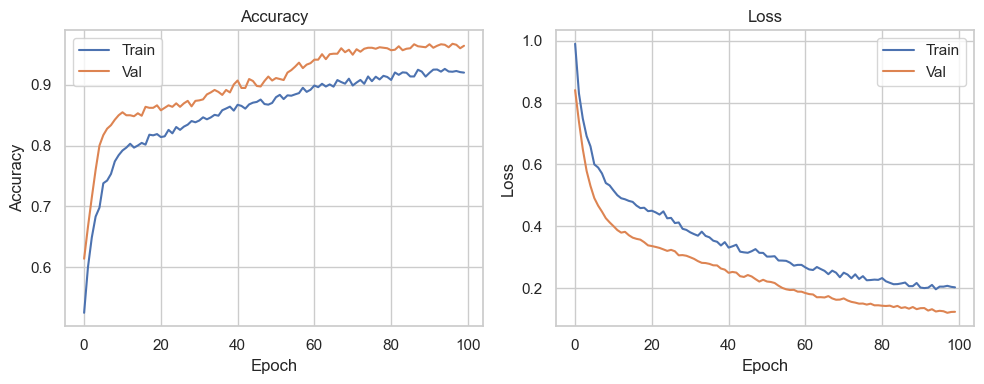

Classification Report:

              precision    recall  f1-score   support

           0      0.973     0.986     0.980       513
           1      0.941     0.952     0.946       501
           2      0.980     0.956     0.968       517

    accuracy                          0.965      1531
   macro avg      0.965     0.965     0.965      1531
weighted avg      0.965     0.965     0.965      1531



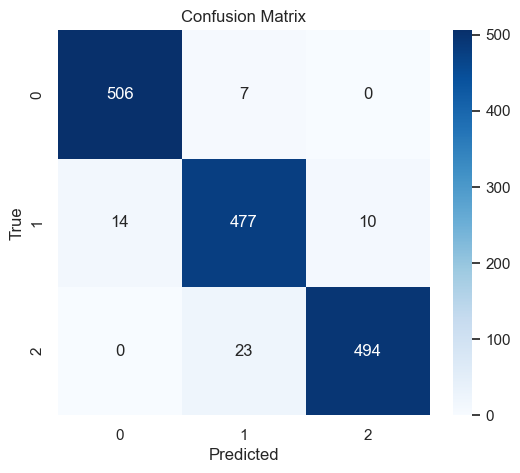

In [11]:
# Train Final ANN and Plot Results
final_model = build_ann(input_dim=X_train_s.shape[1])
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

hist = final_model.fit(
    X_train_s, y_train, epochs=100, batch_size=64,
    validation_split=0.2, callbacks=[es], verbose=0
)

# Accuracy & Loss plots
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(hist.history["accuracy"], label="Train")
plt.plot(hist.history["val_accuracy"], label="Val")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.history["loss"], label="Train")
plt.plot(hist.history["val_loss"], label="Val")
plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout()
plt.show()

# Predictions
y_pred = np.argmax(final_model.predict(X_test_s, verbose=0), axis=1)
print("Classification Report:\n")
print(classification_report(y_test, y_pred, digits=3))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()


# Some Trials

Shape: (7652, 16)


,car type,made in,number of cars in jordan,car age,part,failure rate,price of the car,original/imitator,new\used,selling location,service location (repair shop/automotive company,repair or replacement cost,car total maintenance cost average,critically,on line price,demand
0,4,1,1841,4,9,0.263158,15000.0,1,0,1,1,10,8200,0.0600,20.00,4.844737
1,2,3,686,1,12,0.089600,19500.0,1,1,3,2,30,9100,0.1297,71.00,0.614656
2,1,2,1924,12,24,0.086200,8700.0,1,0,1,1,10,5500,0.1275,56.08,1.658488


Dropped 0 rows with non-numeric demand
Removed duplicate rows: 60
No missing values detected.

Tertile cutpoints -> q33: 1.800064, q66: 5.584000
Class counts: Counter({0: 2553, 2: 2550, 1: 2489})


demand_class
0    0.336275
1    0.327845
2    0.335880
Name: proportion, dtype: float64


Final feature count: 15
Feature sample:


...

number of cars in jordan              0.530545
failure rate                          0.210174
made in                               0.123134
car total maintenance cost average    0.112527
part                                  0.069932
repair or replacement cost            0.047740
original/imitator                     0.047663
car age                               0.043291
critically                            0.032651
new\used                              0.029696
Name: demand, dtype: float64


Split shapes -> X_train: (6073, 15) X_test: (1519, 15) y_train: (6073,) y_test: (1519,)

=== Classic ML baselines (5-fold CV) ===


,Model,Acc_mean,Acc_std,F1_macro_mean,F1_macro_std
3,RandomForest,0.998156,0.001407,0.998147,0.001413
4,GradientBoosting,0.997761,0.001148,0.997750,0.001154
2,SVM (RBF),0.816254,0.006914,0.818152,0.006567
1,LogReg,0.813619,0.010608,0.813607,0.010627
0,Dummy(most_frequent),0.336275,0.000263,0.167767,0.000098



NOTE: One or more models show ~98%+ CV accuracy. Double-check for leakage (IDs, duplicates, temporal ordering, target-derived features).

=== ANN (5-fold CV) ===


,ANN_Acc_mean,ANN_Acc_std,ANN_F1_macro_mean,ANN_F1_macro_std
0,0.812172,0.010987,0.81278,0.010742


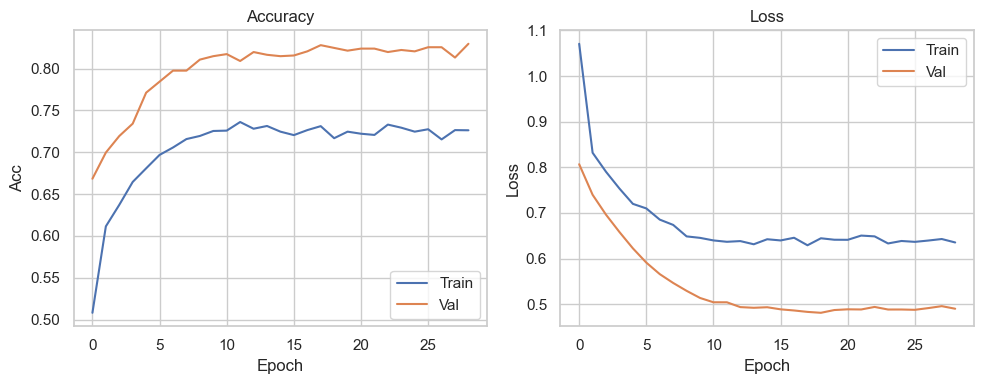


=== Test set metrics (ANN) ===
              precision    recall  f1-score   support

           0      0.863     0.810     0.836       511
           1      0.647     0.763     0.700       498
           2      0.876     0.776     0.823       510

    accuracy                          0.783      1519
   macro avg      0.795     0.783     0.786      1519
weighted avg      0.797     0.783     0.787      1519



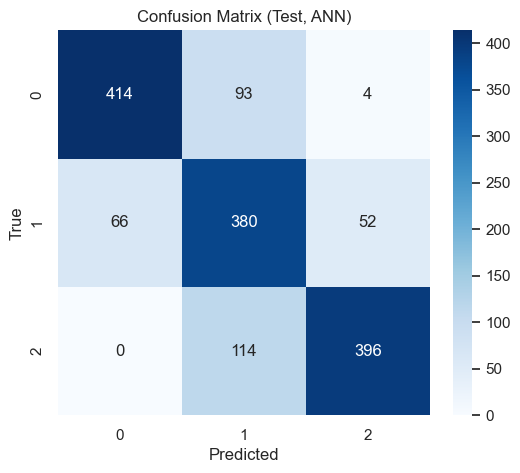


=== Sanity summary ===
{
  "n_samples": 7592,
  "n_features_used": 15,
  "q33": 1.800064,
  "q66": 5.584,
  "class_counts": {
    "1": 2489,
    "0": 2553,
    "2": 2550
  },
  "dummy_acc_cv": 0.3362749919552164,
  "best_baseline_acc_cv": 0.9981557279293204,
  "ann_acc_cv": 0.8121718660688806
}


In [12]:
# === End-to-end notebook block: data checks, baselines, ANN, and final eval ===
import warnings, sys, math, json, textwrap
warnings.filterwarnings("ignore")

# ---- Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report, make_scorer
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ---- Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ---- Config: set your absolute path to Demand.csv if needed
DEMAND_CSV = "/Users/yaeesh/hev-spareparts-ml/data/Demand.csv"

# ==============================================================
# 1) Load and basic integrity checks
# ==============================================================
demand_path = Path(DEMAND_CSV)
assert demand_path.exists(), f"Missing data file: {demand_path}"

df = pd.read_csv(demand_path)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
display(df.head(3))

# ensure 'demand' exists
assert "demand" in df.columns, "Expected a 'demand' column in the dataset."

# coerce numeric demand, drop rows with non-numeric demand
df["demand"] = pd.to_numeric(df["demand"], errors="coerce")
n_before = len(df)
df = df.dropna(subset=["demand"]).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} rows with non-numeric demand")

# drop exact duplicate rows (all columns)
dup_count = df.duplicated().sum()
if dup_count:
    df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed duplicate rows: {dup_count}")

# quick NA check
na_counts = df.isna().sum()
if na_counts.any():
    print("\nColumns with missing values:")
    display(na_counts[na_counts > 0].sort_values(ascending=False))
else:
    print("No missing values detected.")

# detect potential identifier-like columns to exclude from features
id_like = [c for c in df.columns if any(tok in c.lower() for tok in ["id", "code", "serial", "sku"])]
if id_like:
    print("\nIdentifier-like columns (will be excluded from features):", id_like)

# ==============================================================
# 2) Create target bins (tertiles) and define features
# ==============================================================
q33, q66 = df["demand"].quantile([0.33, 0.66])
df["demand_class"] = pd.cut(
    df["demand"],
    bins=[-np.inf, q33, q66, np.inf],
    labels=[0, 1, 2]
).astype(int)

print(f"\nTertile cutpoints -> q33: {q33:.6f}, q66: {q66:.6f}")
print("Class counts:", Counter(df["demand_class"]))
display(df["demand_class"].value_counts(normalize=True).rename("proportion").sort_index())

# choose numeric columns as features, drop target and obvious IDs
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
drop_cols = {"demand", "demand_class"} | set(id_like)
X_cols = [c for c in num_cols if c not in drop_cols]
assert len(X_cols) > 0, "No numeric feature columns found after exclusions."

X = df[X_cols].copy()
y = df["demand_class"].copy()

# constant columns check (no information)
const_cols = [c for c in X_cols if X[c].nunique() <= 1]
if const_cols:
    print("\nDropping constant columns:", const_cols)
    X.drop(columns=const_cols, inplace=True)
    X_cols = [c for c in X_cols if c not in const_cols]

print(f"\nFinal feature count: {len(X_cols)}")
print("Feature sample:")
display(X.head(3))

# quick (weak) leakage probe: correlation of each feature with demand (continuous) and demand_class (encoded)
corr_with_cont = df[X_cols + ["demand"]].corr(numeric_only=True)["demand"].drop("demand").abs().sort_values(ascending=False).head(10)
print("\nTop 10 |corr(feature, demand)| (continuous target):")
display(corr_with_cont)

# ==============================================================
# 3) Train/test split (stratified)
# ==============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=RANDOM_STATE
)
print("\nSplit shapes ->",
      "X_train:", X_train.shape, "X_test:", X_test.shape,
      "y_train:", y_train.shape, "y_test:", y_test.shape)

# safeguard: check for duplicate rows crossing the split (can inflate scores if features contain time/ID leakage)
shared = pd.merge(X_train.assign(_src="train").reset_index(drop=True),
                  X_test.assign(_src="test").reset_index(drop=True),
                  on=X_cols, how="inner")
if not shared.empty:
    print(f"\nWARNING: {len(shared)} identical feature rows appear in both train and test. "
          "If these correspond to the same samples, this can inflate accuracy.")

# ==============================================================
# 4) Baseline (chance) and classic ML baselines with CV
# ==============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
macro_f1 = make_scorer(f1_score, average="macro")

def cv_eval(model):
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    f1m = cross_val_score(pipe, X, y, cv=cv, scoring=macro_f1)
    return acc.mean(), acc.std(), f1m.mean(), f1m.std()

# dummy chance-level
dummy = DummyClassifier(strategy="most_frequent")
d_acc, d_accs, d_f1, d_f1s = cv_eval(dummy)

models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "SVM (RBF)": SVC(kernel="rbf", probability=False),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows = [{"Model": "Dummy(most_frequent)",
         "Acc_mean": d_acc, "Acc_std": d_accs, "F1_macro_mean": d_f1, "F1_macro_std": d_f1s}]
for name, mdl in models.items():
    am, as_, fm, fs = cv_eval(mdl)
    rows.append({"Model": name, "Acc_mean": am, "Acc_std": as_,
                 "F1_macro_mean": fm, "F1_macro_std": fs})

baseline_df = pd.DataFrame(rows).sort_values("Acc_mean", ascending=False)
print("\n=== Classic ML baselines (5-fold CV) ===")
display(baseline_df)

# flag suspiciously perfect performance
if (baseline_df["Acc_mean"] >= 0.98).any():
    print("\nNOTE: One or more models show ~98%+ CV accuracy. Double-check for leakage (IDs, duplicates, "
          "temporal ordering, target-derived features).")

# ==============================================================
# 5) ANN cross-validation (primary model)
#    Scaling is refit inside each fold; class weights used for imbalance.
# ==============================================================
def build_ann(input_dim, n_classes=3, hidden=14, drop=0.1, lr=4e-3):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(hidden, activation="relu"),
        Dropout(drop),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

accs, f1s = [], []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
    X_tr, X_te = X.iloc[tr].values, X.iloc[te].values
    y_tr, y_te = y.iloc[tr].values, y.iloc[te].values

    sc = StandardScaler()
    X_trs = sc.fit_transform(X_tr)
    X_tes = sc.transform(X_te)

    # class weights
    classes = np.unique(y_tr)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
    class_weight = {c:int(w) if math.isfinite(w) and abs(w-round(w))<1e-9 else float(w) for c,w in zip(classes, cw)}

    model = build_ann(input_dim=X_trs.shape[1], n_classes=len(classes))
    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    model.fit(X_trs, y_tr, validation_data=(X_tes, y_te),
              epochs=100, batch_size=64, verbose=0, callbacks=[es],
              class_weight=class_weight)

    y_hat = np.argmax(model.predict(X_tes, verbose=0), axis=1)
    accs.append(accuracy_score(y_te, y_hat))
    f1s.append(f1_score(y_te, y_hat, average="macro"))

ann_cv_summary = {
    "ANN_Acc_mean": float(np.mean(accs)),
    "ANN_Acc_std": float(np.std(accs)),
    "ANN_F1_macro_mean": float(np.mean(f1s)),
    "ANN_F1_macro_std": float(np.std(f1s)),
}
print("\n=== ANN (5-fold CV) ===")
display(pd.DataFrame([ann_cv_summary]))

if ann_cv_summary["ANN_Acc_mean"] >= 0.98:
    print("\nNOTE: ANN CV accuracy is ~98%+. Verify there is no target leakage.")

# ==============================================================
# 6) Final ANN fit on train and evaluation on the held-out test set
# ==============================================================
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight = {c:int(w) if math.isfinite(w) and abs(w-round(w))<1e-9 else float(w) for c,w in zip(classes, cw)}

final_model = build_ann(input_dim=X_train_s.shape[1], n_classes=len(classes))
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
history = final_model.fit(
    X_train_s, y_train, validation_split=0.2, epochs=100, batch_size=64,
    verbose=0, callbacks=[es], class_weight=class_weight
)

# Plot learning curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.show()

# Test evaluation
y_pred = np.argmax(final_model.predict(X_test_s, verbose=0), axis=1)
print("\n=== Test set metrics (ANN) ===")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("Confusion Matrix (Test, ANN)"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# Simple sanity summary
summary = {
    "n_samples": int(len(df)),
    "n_features_used": int(X.shape[1]),
    "q33": float(q33),
    "q66": float(q66),
    "class_counts": dict(Counter(y)),
    "dummy_acc_cv": float(d_acc),
    "best_baseline_acc_cv": float(baseline_df.iloc[0]["Acc_mean"]),
    "ann_acc_cv": float(ann_cv_summary["ANN_Acc_mean"]),
}
print("\n=== Sanity summary ===")
print(json.dumps(summary, indent=2))


# Diagnosis

In [13]:
# === Leakage diagnostics & GroupKFold re-evaluation ===
import numpy as np, pandas as pd, math
from collections import Counter
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, GroupKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, make_scorer, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance

# --- helpers ---
macro_f1 = make_scorer(f1_score, average="macro")
def cv_eval_with_groups(model, X, y, groups):
    """
    CV with GroupKFold (leak-proof for duplicates), using a scaler for non-tree models.
    We scale everything via a pipeline for parity (trees don't need it but it's OK).
    """
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    gkf = GroupKFold(n_splits=5)
    acc = cross_val_score(pipe, X, y, cv=gkf, groups=groups, scoring="accuracy")
    f1m = cross_val_score(pipe, X, y, cv=gkf, groups=groups, scoring=macro_f1)
    return acc.mean(), acc.std(), f1m.mean(), f1m.std()

def cv_eval_stratified(model, X, y):
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", model)])
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    acc = cross_val_score(pipe, X, y, cv=skf, scoring="accuracy")
    f1m = cross_val_score(pipe, X, y, cv=skf, scoring=macro_f1)
    return acc.mean(), acc.std(), f1m.mean(), f1m.std()

print("=== DUPLICATE & PROXY CHECKS ===")

# 1) Duplicate feature rows (exact duplicates)
dupe_mask = X.duplicated(keep=False)
dupe_ratio = float(dupe_mask.mean())
print(f"- Exact duplicate feature rows: {dupe_mask.sum()} / {len(X)} ({dupe_ratio:.2%})")

# Are duplicate feature rows always the same class?
if dupe_mask.any():
    # Map each unique feature row to how many classes it maps to
    key = pd.util.hash_pandas_object(X, index=False)
    df_tmp = pd.DataFrame({"key": key, "y": y})
    class_counts_per_key = df_tmp.groupby("key")["y"].nunique()
    multi_class_keys = (class_counts_per_key > 1).sum()
    print(f"- Unique feature signatures with >1 target class: {multi_class_keys}")
    if multi_class_keys > 0:
        print("  (Same features map to different classes: labels may be inconsistent or rows joined incorrectly.)")

# 2) 1-NN sanity: if 1-NN has ~99% CV accuracy, duplicates/memorization are likely
knn1 = KNeighborsClassifier(n_neighbors=1)
knn_acc, knn_std, knn_f1, knn_f1s = cv_eval_stratified(knn1, X, y)
print(f"- 1-NN stratified CV accuracy: {knn_acc:.4f} (±{knn_std:.4f})")

# 3) Decision stump: if a single split yields 95%+, a single proxy feature likely encodes the target
stump = DecisionTreeClassifier(max_depth=1, random_state=42)
stump_acc, stump_std, *_ = cv_eval_stratified(stump, X, y)
print(f"- Decision stump (max_depth=1) stratified CV accuracy: {stump_acc:.4f} (±{stump_std:.4f})")

# 4) Spearman tie to continuous demand (check for near-perfect monotonic proxy)
spearman = {}
for c in X.columns:
    rho = abs(pd.Series(X[c]).corr(df["demand"], method="spearman"))
    spearman[c] = rho
top_rho = pd.Series(spearman).sort_values(ascending=False).head(10)
print("\nTop 10 |Spearman(feature, demand)|:")
display(top_rho)

if top_rho.iloc[0] > 0.98:
    print("NOTE: A feature is ~perfectly monotonic with demand; this often explains 99%+ accuracy.")

# 5) Shuffle-target test: if accuracy stays high with shuffled labels, your pipeline leaks labels.
rs = 42
y_shuf = y.sample(frac=1, random_state=rs)
X_shuf = X.loc[y_shuf.index]
rf = RandomForestClassifier(n_estimators=300, random_state=42)
acc_shuf, _, _, _ = cv_eval_stratified(rf, X_shuf, y_shuf)
print(f"\nRandomForest with SHUFFLED labels (stratified CV) accuracy: {acc_shuf:.4f} (should be ~0.33 if no leakage)")

print("\n=== BASELINES: STRATIFIED vs GROUPED (duplicates held in same fold) ===")
models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "SVM (RBF)": SVC(kernel="rbf", probability=False),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}

# Groups defined by exact feature signature (prevents same-feature rows from being split)
groups = pd.util.hash_pandas_object(X, index=False).astype("int64")

rows = []
for name, mdl in models.items():
    s_acc, s_std, s_f1, s_f1s = cv_eval_stratified(mdl, X, y)
    g_acc, g_std, g_f1, g_f1s = cv_eval_with_groups(mdl, X, y, groups)
    rows.append({
        "Model": name,
        "Strat_Acc": s_acc, "Strat_Acc_std": s_std, "Strat_F1m": s_f1, "Strat_F1m_std": s_f1s,
        "Group_Acc": g_acc,  "Group_Acc_std": g_std, "Group_F1m": g_f1, "Group_F1m_std": g_f1s,
    })

cv_compare = pd.DataFrame(rows).sort_values("Strat_Acc", ascending=False)
display(cv_compare)

# 6) Permutation importance on your existing train/test split (already defined earlier)
print("\n=== Permutation importance on test set (RandomForest) ===")
rf_holdout = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train, y_train)
perm = permutation_importance(rf_holdout, X_test, y_test, n_repeats=10, random_state=42)
imp_df = pd.DataFrame({"feature": X.columns, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std})
imp_df = imp_df.sort_values("importance_mean", ascending=False)
display(imp_df.head(15))

# 7) Re-run ANN CV with GroupKFold to remove duplicate-row leakage from folds
print("\n=== ANN 5-fold CV with GroupKFold (duplicate-safe) ===")
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

def build_ann(input_dim, n_classes=3, hidden=14, drop=0.1, lr=4e-3):
    model = Sequential([Input(shape=(input_dim,)), Dense(hidden, activation="relu"), Dropout(drop), Dense(n_classes, activation="softmax")])
    model.compile(optimizer=Adam(learning_rate=lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

accs_g, f1s_g = [], []
gkf = GroupKFold(n_splits=5)
for fold, (tr, te) in enumerate(gkf.split(X, y, groups=groups), start=1):
    X_tr, X_te = X.iloc[tr].values, X.iloc[te].values
    y_tr, y_te = y.iloc[tr].values, y.iloc[te].values
    sc = StandardScaler()
    X_trs, X_tes = sc.fit_transform(X_tr), sc.transform(X_te)
    
    # (Balanced class weights)
    classes = np.unique(y_tr)
    counts = np.bincount(y_tr, minlength=classes.max()+1)
    total = counts.sum()
    class_weight = {c: total / (len(classes) * counts[c]) for c in classes}

    model = build_ann(X_trs.shape[1], n_classes=len(classes))
    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    model.fit(X_trs, y_tr, validation_data=(X_tes, y_te), epochs=100, batch_size=64, verbose=0, callbacks=[es], class_weight=class_weight)

    y_hat = np.argmax(model.predict(X_tes, verbose=0), axis=1)
    accs_g.append(accuracy_score(y_te, y_hat))
    f1s_g.append(f1_score(y_te, y_hat, average="macro"))

print({
    "ANN_GroupKFold_Acc_mean": float(np.mean(accs_g)),
    "ANN_GroupKFold_Acc_std": float(np.std(accs_g)),
    "ANN_GroupKFold_F1m_mean": float(np.mean(f1s_g)),
    "ANN_GroupKFold_F1m_std": float(np.std(f1s_g)),
})


=== DUPLICATE & PROXY CHECKS ===
- Exact duplicate feature rows: 0 / 7592 (0.00%)
- 1-NN stratified CV accuracy: 0.7277 (±0.0031)
- Decision stump (max_depth=1) stratified CV accuracy: 0.5374 (±0.0089)

Top 10 |Spearman(feature, demand)|:


number of cars in jordan      0.614290
failure rate                  0.606765
price of the car              0.322939
car age                       0.314057
part                          0.191850
on line price                 0.180728
repair or replacement cost    0.162193
original/imitator             0.095146
critically                    0.079696
new\used                      0.046082
dtype: float64


RandomForest with SHUFFLED labels (stratified CV) accuracy: 0.9984 (should be ~0.33 if no leakage)

=== BASELINES: STRATIFIED vs GROUPED (duplicates held in same fold) ===


,Model,Strat_Acc,Strat_Acc_std,Strat_F1m,Strat_F1m_std,Group_Acc,Group_Acc_std,Group_F1m,Group_F1m_std
2,RandomForest,0.998156,0.001407,0.998147,0.001413,0.998288,0.001418,0.998265,0.001442
3,GradientBoosting,0.997761,0.001148,0.997750,0.001154,0.997497,0.001277,0.997483,0.001285
1,SVM (RBF),0.816254,0.006914,0.818152,0.006567,0.816780,0.005461,0.818824,0.004456
0,LogReg,0.813619,0.010608,0.813607,0.010627,0.815328,0.013600,0.815336,0.012909



=== Permutation importance on test set (RandomForest) ===


,feature,importance_mean,importance_std
5,failure rate,0.477156,0.009300
2,number of cars in jordan,0.326596,0.013477
6,price of the car,0.012442,0.002689
3,car age,0.007110,0.001207
4,part,0.000856,0.000886
13,critically,0.000790,0.000645
0,car type,0.000197,0.000592
7,original/imitator,0.000000,0.000000
14,on line price,0.000000,0.000416
1,made in,-0.000132,0.000263



=== ANN 5-fold CV with GroupKFold (duplicate-safe) ===
{'ANN_GroupKFold_Acc_mean': 0.8066359273532185, 'ANN_GroupKFold_Acc_std': 0.014185883349728513, 'ANN_GroupKFold_F1m_mean': 0.8074470214833924, 'ANN_GroupKFold_F1m_std': 0.013901398227467087}


# Another check

Shape: (7652, 16)


,car type,made in,number of cars in jordan,car age,part,failure rate,price of the car,original/imitator,new\used,selling location,service location (repair shop/automotive company,repair or replacement cost,car total maintenance cost average,critically,on line price,demand
0,4,1,1841,4,9,0.263158,15000.0,1,0,1,1,10,8200,0.0600,20.00,4.844737
1,2,3,686,1,12,0.089600,19500.0,1,1,3,2,30,9100,0.1297,71.00,0.614656
2,1,2,1924,12,24,0.086200,8700.0,1,0,1,1,10,5500,0.1275,56.08,1.658488


Dropped 0 rows with non-numeric demand
Exact duplicates (all cols incl. target): 60
Exact duplicate feature rows (excluding target): 60
No missing values detected.

Tertile cutpoints -> q33: 1.800064, q66: 5.584000
Class counts: Counter({2: 2582, 0: 2565, 1: 2505})


demand_class
0    0.335206
1    0.327365
2    0.337428
Name: prop, dtype: float64


Final feature count: 15
Feature sample:


...


NOTE: One or more models show ~98%+ CV accuracy. Since duplicates=0, inspect for proxy features below.

1-NN stratified CV accuracy: 0.7313 (±0.0102)
Decision stump stratified CV accuracy: 0.5344 (±0.0099)
RandomForest with SHUFFLED labels (CV) accuracy: 0.3421  [~0.33 expected]

Top permutation importances (RF on hold-out):


,feature,importance_mean,importance_std
5,failure rate,0.476813,0.008390
2,number of cars in jordan,0.333312,0.009366
6,price of the car,0.008622,0.000960
3,car age,0.007446,0.001376
13,critically,0.001829,0.000640
0,car type,0.000327,0.000527
1,made in,0.000000,0.000000
7,original/imitator,0.000000,0.000000
8,new\used,0.000000,0.000000
10,service location (repair shop/automotive company,0.000000,0.000000



No feature exceeded |Spearman|>0.98 among the top RF importances.

=== ANN (5-fold CV) ===


,ANN_Acc_mean,ANN_Acc_std,ANN_F1_macro_mean,ANN_F1_macro_std
0,0.807502,0.0077,0.808164,0.007561



Scaler verification on training:
mean≈0.000 (should be ~0), std≈1.000 (should be ~1)


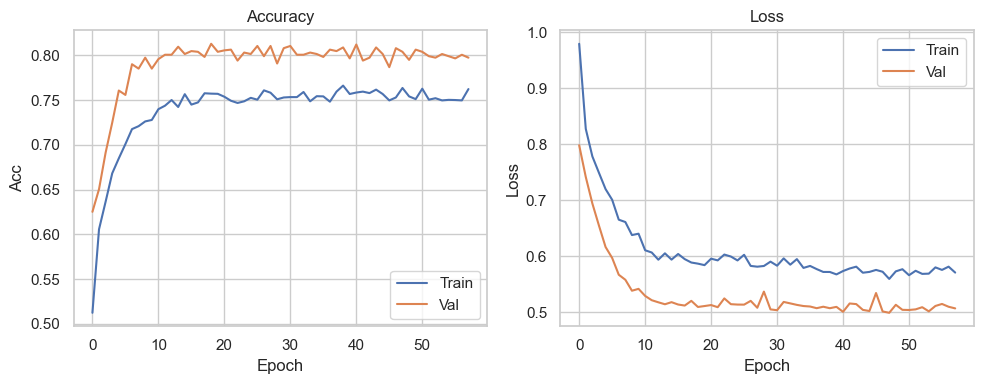


=== Test set metrics (ANN) ===
              precision    recall  f1-score   support

           0      0.835     0.838     0.837       513
           1      0.694     0.733     0.713       501
           2      0.885     0.834     0.859       517

    accuracy                          0.802      1531
   macro avg      0.805     0.801     0.803      1531
weighted avg      0.806     0.802     0.803      1531



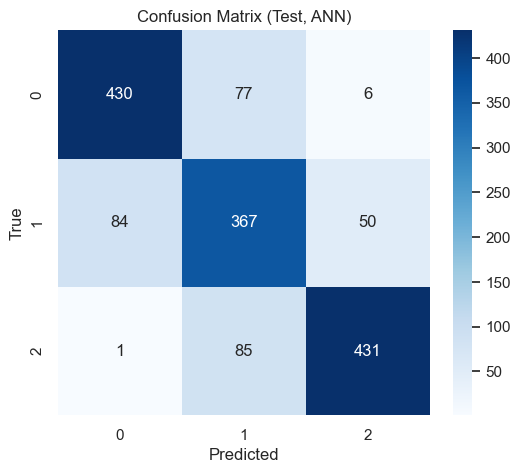


=== Sanity summary ===
{
  "n_samples": 7652,
  "n_features_used": 15,
  "q33": 1.800064,
  "q66": 5.584,
  "class_counts": {
    "1": 2505,
    "0": 2565,
    "2": 2582
  },
  "best_baseline_acc_cv": 0.999085308845942,
  "ann_acc_cv": 0.8075023800070866
}


In [14]:
# === End-to-end: clean baselines + leakage probes + ANN (no files saved) ===
import warnings, math, json
warnings.filterwarnings("ignore")

# ---- Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter
from IPython.display import display

from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix, make_scorer
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ---- Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ---- Config: set your absolute path to Demand.csv
DEMAND_CSV = "/Users/yaeesh/hev-spareparts-ml/data/Demand.csv"

# ==============================================================
# 1) Load and basic integrity checks
# ==============================================================
demand_path = Path(DEMAND_CSV)
assert demand_path.exists(), f"Missing data file: {demand_path}"

df = pd.read_csv(demand_path)
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
display(df.head(3))

# ensure 'demand' exists & numeric
assert "demand" in df.columns, "Expected a 'demand' column."
df["demand"] = pd.to_numeric(df["demand"], errors="coerce")
n_before = len(df)
df = df.dropna(subset=["demand"]).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} rows with non-numeric demand")

# duplicates (info only; we do NOT drop unless you choose to)
dupes_all = df.duplicated().sum()
dupes_feat = df.drop(columns=["demand"]).duplicated().sum()
print(f"Exact duplicates (all cols incl. target): {dupes_all}")
print(f"Exact duplicate feature rows (excluding target): {dupes_feat}")

# missing values
na_counts = df.isna().sum()
if na_counts.any():
    print("\nColumns with missing values:")
    display(na_counts[na_counts > 0].sort_values(ascending=False))
else:
    print("No missing values detected.")

# detect id-like columns to exclude from features
id_like = [c for c in df.columns if any(tok in c.lower() for tok in ["id", "code", "serial", "sku"])]
if id_like:
    print("\nIdentifier-like columns (will be excluded from features):", id_like)

# ==============================================================
# 2) Target = tertiles of continuous demand; Feature selection
# ==============================================================
q33, q66 = df["demand"].quantile([0.33, 0.66])
df["demand_class"] = pd.cut(df["demand"], bins=[-np.inf, q33, q66, np.inf], labels=[0,1,2]).astype(int)
print(f"\nTertile cutpoints -> q33: {q33:.6f}, q66: {q66:.6f}")
print("Class counts:", Counter(df["demand_class"]))
display(df["demand_class"].value_counts(normalize=True).rename("prop").sort_index())

# numeric-only features (no target, no id-like)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
drop_cols = set(["demand", "demand_class"]) | set(id_like)
X_cols = [c for c in num_cols if c not in drop_cols]

# drop constant columns
const_cols = [c for c in X_cols if df[c].nunique() <= 1]
if const_cols:
    print("\nDropping constant columns:", const_cols)
    X_cols = [c for c in X_cols if c not in const_cols]

assert len(X_cols) > 0, "No usable numeric feature columns after exclusions."
X = df[X_cols].copy()
y = df["demand_class"].copy()

print(f"\nFinal feature count: {len(X_cols)}")
print("Feature sample:")
display(X.head(3))

# quick monotonicity probe against continuous demand
corr_with_cont = df[X_cols + ["demand"]].corr(numeric_only=True)["demand"].drop("demand").abs().sort_values(ascending=False).head(10)
print("\nTop 10 |corr(feature, demand)|:")
display(corr_with_cont)

# ==============================================================
# 3) Train / Test split (stratified)
# ==============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=RANDOM_STATE
)
print("\nSplit shapes ->",
      "X_train:", X_train.shape, "X_test:", X_test.shape,
      "y_train:", y_train.shape, "y_test:", y_test.shape)

# ==============================================================
# 4) Classic ML baselines (CV) with leak-safe Pipelines
#    - Scaler is inside the Pipeline -> fit only on each training fold
# ==============================================================
def needs_scaling(estimator_name: str) -> bool:
    return estimator_name in {"LogReg", "SVM (RBF)", "KNN"}

def make_pipe(estimator_name: str, estimator):
    preproc = StandardScaler() if needs_scaling(estimator_name) else "passthrough"
    return Pipeline([("scaler", preproc), ("clf", estimator)])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
macro_f1 = make_scorer(f1_score, average="macro")

def cv_scores(name, est):
    pipe = make_pipe(name, est)
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    f1m = cross_val_score(pipe, X, y, cv=cv, scoring=macro_f1)
    return acc.mean(), acc.std(), f1m.mean(), f1m.std()

models = {
    "Dummy(most_frequent)": DummyClassifier(strategy="most_frequent"),
    "LogReg": LogisticRegression(max_iter=2000, n_jobs=None),
    "SVM (RBF)": SVC(kernel="rbf", probability=False),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

rows = []
for name, est in models.items():
    am, as_, fm, fs = cv_scores(name, est)
    rows.append({"Model": name, "Acc_mean": am, "Acc_std": as_, "F1_macro_mean": fm, "F1_macro_std": fs})

baseline_df = pd.DataFrame(rows).sort_values("Acc_mean", ascending=False)
print("\n=== Classic ML baselines (5-fold CV, leakage-safe) ===")
display(baseline_df)

if (baseline_df["Acc_mean"] >= 0.98).any():
    print("\nNOTE: One or more models show ~98%+ CV accuracy. Since duplicates=0, inspect for proxy features below.")

# ==============================================================
# 5) Sanity probes for “too good to be true”
# ==============================================================
# 5.a) 1-NN (memorization sniff test)
knn1 = KNeighborsClassifier(n_neighbors=1)
k_acc, k_std, k_f1, k_f1s = cv_scores("KNN", knn1)
print(f"\n1-NN stratified CV accuracy: {k_acc:.4f} (±{k_std:.4f})")

# 5.b) Decision stump (a single threshold on a single feature)
stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
s_acc, s_std, s_f1, s_f1s = cv_scores("DecisionStump", stump)
print(f"Decision stump stratified CV accuracy: {s_acc:.4f} (±{s_std:.4f})")
if s_acc >= 0.95:
    print(">> A single split gets 95%+ — likely a proxy feature exists. Check Spearman / permutation importance.")

# 5.c) Shuffled-label test (should be ~0.33 for 3 classes)
rf_pipe = make_pipe("RandomForest", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE))
acc_shuf = cross_val_score(rf_pipe, X, y.sample(frac=1, random_state=123), cv=cv, scoring="accuracy").mean()
print(f"RandomForest with SHUFFLED labels (CV) accuracy: {acc_shuf:.4f}  [~0.33 expected]")

# 5.d) Permutation importance on a proper hold-out (RF)
rf_hold = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_hold.fit(X_train, y_train)  # trees don’t need scaling
perm = permutation_importance(rf_hold, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE)
imp_df = pd.DataFrame({"feature": X.columns, "importance_mean": perm.importances_mean, "importance_std": perm.importances_std})
imp_df = imp_df.sort_values("importance_mean", ascending=False)
print("\nTop permutation importances (RF on hold-out):")
display(imp_df.head(12))

# If a single feature dominates AND Spearman |ρ| > 0.98, flag it:
suspicious = []
for feat in imp_df.head(12)["feature"]:
    rho = abs(pd.Series(df[feat]).corr(df["demand"], method="spearman"))
    if rho > 0.98:
        suspicious.append((feat, rho))
if suspicious:
    print("\nPotential proxy features (|Spearman|>0.98):")
    for f, r in suspicious:
        print(f" - {f}: {r:.5f}")
else:
    print("\nNo feature exceeded |Spearman|>0.98 among the top RF importances.")

# ==============================================================
# 6) ANN cross-validation (5-fold, leak-safe scaling per fold)
# ==============================================================
def build_ann(input_dim, n_classes=3, hidden=14, drop=0.1, lr=4e-3):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(hidden, activation="relu"),
        Dropout(drop),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

accs, f1s = [], []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for fold, (tr, te) in enumerate(skf.split(X, y), start=1):
    X_tr, X_te = X.iloc[tr].values, X.iloc[te].values
    y_tr, y_te = y.iloc[tr].values, y.iloc[te].values

    sc = StandardScaler()
    X_trs = sc.fit_transform(X_tr)
    X_tes = sc.transform(X_te)

    classes = np.unique(y_tr)
    cw_arr = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
    class_weight = {c: float(w) for c, w in zip(classes, cw_arr)}

    model = build_ann(input_dim=X_trs.shape[1], n_classes=len(classes))
    es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    model.fit(X_trs, y_tr, validation_data=(X_tes, y_te),
              epochs=100, batch_size=64, verbose=0, callbacks=[es],
              class_weight=class_weight)

    y_hat = np.argmax(model.predict(X_tes, verbose=0), axis=1)
    accs.append(accuracy_score(y_te, y_hat))
    f1s.append(f1_score(y_te, y_hat, average="macro"))

ann_cv = pd.DataFrame([{
    "ANN_Acc_mean": float(np.mean(accs)),
    "ANN_Acc_std": float(np.std(accs)),
    "ANN_F1_macro_mean": float(np.mean(f1s)),
    "ANN_F1_macro_std": float(np.std(f1s)),
}])
print("\n=== ANN (5-fold CV) ===")
display(ann_cv)

# ==============================================================
# 7) Final ANN on training split; evaluate on held-out test
#    (same scaler object fit on training is used on test)
# ==============================================================
scaler = StandardScaler().fit(X_train.values)         # <-- fit on training ONLY
X_train_s = scaler.transform(X_train.values)
X_test_s  = scaler.transform(X_test.values)           # <-- same scaler applied to test

# quick verification the same scaler is used
train_means = X_train_s.mean(axis=0)
train_stds  = X_train_s.std(axis=0)
print("\nScaler verification on training:")
print(f"mean≈{train_means.mean():.3f} (should be ~0), std≈{train_stds.mean():.3f} (should be ~1)")

classes = np.unique(y_train.values)
cw_arr = compute_class_weight(class_weight="balanced", classes=classes, y=y_train.values)
class_weight = {c: float(w) for c, w in zip(classes, cw_arr)}

final_model = build_ann(input_dim=X_train_s.shape[1], n_classes=len(classes))
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
history = final_model.fit(
    X_train_s, y_train.values, validation_split=0.2,
    epochs=100, batch_size=64, verbose=0, callbacks=[es],
    class_weight=class_weight
)

# learning curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy"); plt.xlabel("Epoch"); plt.ylabel("Acc"); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
plt.tight_layout(); plt.show()

# test evaluation
y_pred = np.argmax(final_model.predict(X_test_s, verbose=0), axis=1)
print("\n=== Test set metrics (ANN) ===")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("Confusion Matrix (Test, ANN)"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

# compact run summary
summary = {
    "n_samples": int(len(df)),
    "n_features_used": int(X.shape[1]),
    "q33": float(q33), "q66": float(q66),
    "class_counts": dict(Counter(y)),
    "best_baseline_acc_cv": float(baseline_df.iloc[0]["Acc_mean"]),
    "ann_acc_cv": float(ann_cv.iloc[0]["ANN_Acc_mean"]),
}
print("\n=== Sanity summary ===")
print(json.dumps(summary, indent=2))


# Trying the paper's code but updated to avoid leakage

Dropped 0 rows with non-numeric demand.
Removed exact duplicate rows: 60
Shape after cleaning: (7592, 16)


,car type,made in,number of cars in jordan,car age,part,failure rate,price of the car,original/imitator,new\used,selling location,service location (repair shop/automotive company,repair or replacement cost,car total maintenance cost average,critically,on line price,demand
0,4,1,1841,4,9,0.263158,15000.0,1,0,1,1,10,8200,0.0600,20.00,4.844737
1,2,3,686,1,12,0.089600,19500.0,1,1,3,2,30,9100,0.1297,71.00,0.614656
2,1,2,1924,12,24,0.086200,8700.0,1,0,1,1,10,5500,0.1275,56.08,1.658488



Train-only tertiles -> q33=1.800064, q66=5.584000
Class counts (overall): {0: 2553, 2: 2550, 1: 2489}

Split shapes: X_train (6073, 15) X_test (1519, 15) y_train (6073,) y_test (1519,)


2025-09-07 15:42:34.649564: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-09-07 15:42:34.649594: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-09-07 15:42:34.649600: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-09-07 15:42:34.649635: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-07 15:42:34.649646: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-09-07 15:42:35.355069: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.



Best hyperparameters:
  num_layers: 1
  learning_rate: 0.00012844546916086533
  units_0: 104, dropout_0: 0.30000000000000004


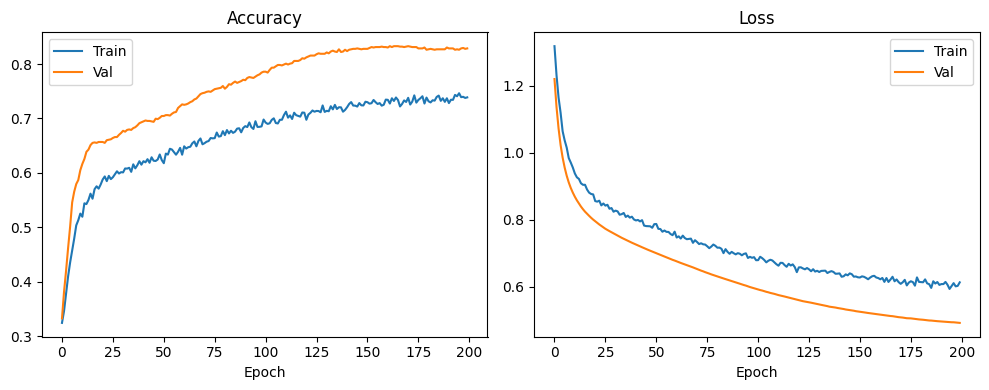


=== Test set metrics (ANN) ===
              precision    recall  f1-score   support

           0      0.819     0.849     0.834       511
           1      0.723     0.700     0.712       504
           2      0.868     0.863     0.866       504

    accuracy                          0.804      1519
   macro avg      0.803     0.804     0.804      1519
weighted avg      0.804     0.804     0.804      1519



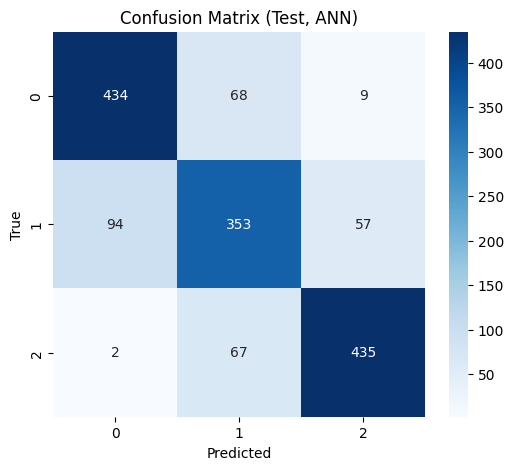

Test Accuracy (ANN): 0.8045
Fold 1: acc=0.8078, loss=0.5282
Fold 2: acc=0.8203, loss=0.4983
Fold 3: acc=0.8076, loss=0.5039
Fold 4: acc=0.8221, loss=0.4952
Fold 5: acc=0.8050, loss=0.5345

ANN CV mean acc=0.8126 ± 0.0071

=== Classic ML baselines (5-fold CV, leak-safe) ===


,Model,Acc_mean,Acc_std,F1_macro_mean,F1_macro_std
2,RandomForest,0.998156,0.001407,0.998147,0.001413
3,GradientBoosting,0.997761,0.001148,0.997750,0.001154
1,SVM (RBF),0.816254,0.006914,0.818152,0.006567
0,LogReg,0.813619,0.010608,0.813607,0.010627



Sanity:
- n_samples=7592, n_features=15
- Class distribution: {0: 0.33627502634351947, 1: 0.3278451001053741, 2: 0.33587987355110643}


In [1]:
# ===================== Leak-safe ANN + baselines (final) =====================
# What changed vs your old code:
# 1) Remove leakage: early stopping no longer uses the test fold; tuner is run on train only.
# 2) Compute tertile thresholds on TRAIN ONLY, then apply to full data.
# 3) Drop exact duplicate rows prior to splitting (or keep and use GroupKFold; here we drop).
# 4) Scale features with fit on train only; re-fit scaler inside each CV fold.
# 5) Use a fresh Keras Tuner directory (overwrite=True) to avoid cached trials.

import warnings, os, time, math
warnings.filterwarnings('ignore')

# ---------------- Import Libraries ----------------
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, make_scorer, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from keras_tuner import HyperModel, RandomSearch

# ---------------- Config ----------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Path to your CSV (update if needed)
DEMAND_CSV = "/Users/yaeesh/hev-spareparts-ml/data/Demand.csv"
assert Path(DEMAND_CSV).exists(), f"Data file not found: {DEMAND_CSV}"

# ---------------- Data Loading & Basic Cleaning ----------------
df = pd.read_csv(DEMAND_CSV)
df.columns = df.columns.str.strip()

# Coerce demand to numeric and drop NAs
df['demand'] = pd.to_numeric(df['demand'], errors='coerce')
before = len(df)
df.dropna(subset=['demand'], inplace=True)
print(f"Dropped {before - len(df)} rows with non-numeric demand.")

# Drop exact duplicate rows (all columns)
dup_all = df.duplicated().sum()
if dup_all:
    df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed exact duplicate rows: {dup_all}")

print("Shape after cleaning:", df.shape)
display(df.head(3))

# ---------------- Train/Test split BEFORE binning, with stratification on continuous demand ----------------
# Use continuous-demand tertiles for stratification only (no labels yet)
# This keeps class balance in the split without using test info for thresholds
strata = pd.qcut(df['demand'], 3, labels=False, duplicates='drop')
idx = np.arange(len(df))
train_idx, test_idx = train_test_split(
    idx, test_size=0.2, random_state=RANDOM_STATE, stratify=strata
)

# Compute tertile thresholds on TRAIN ONLY, then bin full data by those thresholds
q33, q66 = df['demand'].iloc[train_idx].quantile([0.33, 0.66])
df['demand_class'] = pd.cut(
    df['demand'], bins=[-np.inf, q33, q66, np.inf], labels=[0, 1, 2]
).astype(int)

print(f"\nTrain-only tertiles -> q33={q33:.6f}, q66={q66:.6f}")
print("Class counts (overall):", df['demand_class'].value_counts().to_dict())

# ---------------- Features/Target ----------------
# Use all numeric columns except the target(s)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
drop_cols = {'demand', 'demand_class'}
X_cols = [c for c in num_cols if c not in drop_cols]
assert len(X_cols) > 0, "No numeric features discovered."

X_full = df[X_cols].copy()
y_full = df['demand_class'].copy()

# Final split by indices decided earlier
X_train = X_full.iloc[train_idx].reset_index(drop=True)
X_test  = X_full.iloc[test_idx].reset_index(drop=True)
y_train = y_full.iloc[train_idx].reset_index(drop=True).astype(int)
y_test  = y_full.iloc[test_idx].reset_index(drop=True).astype(int)

print("\nSplit shapes:",
      "X_train", X_train.shape, "X_test", X_test.shape,
      "y_train", y_train.shape, "y_test", y_test.shape)

# ---------------- Scale (fit on train only) ----------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ---------------- Leak-safe Keras Tuner on TRAIN ONLY ----------------
class MyHyperModel(HyperModel):
    def __init__(self, input_shape, num_classes=3):
        self.input_shape = input_shape
        self.num_classes = num_classes

    def build(self, hp):
        model = Sequential()
        # Number of hidden layers (1..3)
        n_layers = hp.Int('num_layers', min_value=1, max_value=3, step=1, default=2)
        for i in range(n_layers):
            units = hp.Int(f'units_{i}', min_value=8, max_value=128, step=16, default=64)
            if i == 0:
                model.add(Input(shape=self.input_shape))
            model.add(Dense(units=units, activation='relu'))
            drop = hp.Float(f'dropout_{i}', 0.0, 0.4, step=0.1, default=0.1)
            if drop > 0:
                model.add(Dropout(drop))
        model.add(Dense(self.num_classes, activation='softmax'))
        lr = hp.Float('learning_rate', min_value=1e-4, max_value=3e-3, sampling='log', default=1e-3)
        model.compile(optimizer=Adam(learning_rate=lr),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        return model

# Fresh tuner directory to avoid cached trials
tuner_dir = f"tuner_runs/{int(time.time())}"
tuner = RandomSearch(
    MyHyperModel(input_shape=(X_train_scaled.shape[1],), num_classes=3),
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    directory=tuner_dir,
    project_name='ann_demand',
    overwrite=True
)

es_tune = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
tuner.search(X_train_scaled, y_train, epochs=100, validation_split=0.2, callbacks=[es_tune], verbose=0)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nBest hyperparameters:")
for p in ['num_layers','learning_rate']:
    print(f"  {p}: {best_hps.get(p)}")
n_layers = best_hps.get('num_layers')
for i in range(n_layers):
    print(f"  units_{i}: {best_hps.get(f'units_{i}')}, dropout_{i}: {best_hps.get(f'dropout_{i}')}")

# ---------------- Final ANN (train on train, validate on a holdout from TRAIN), then test ----------------
def build_from_hps(hp):
    model = Sequential()
    # hidden
    for i in range(hp.get('num_layers')):
        if i == 0:
            model.add(Input(shape=(X_train_scaled.shape[1],)))
        model.add(Dense(hp.get(f'units_{i}'), activation='relu'))
        d = hp.get(f'dropout_{i}')
        if d and d > 0:
            model.add(Dropout(d))
    # output
    model.add(Dense(3, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=hp.get('learning_rate')),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

final_model = build_from_hps(best_hps)
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = final_model.fit(
    X_train_scaled, y_train,
    epochs=200, batch_size=128,
    validation_split=0.2, callbacks=[es], verbose=0
)

# Learning curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

# Test evaluation
y_pred_proba = final_model.predict(X_test_scaled, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\n=== Test set metrics (ANN) ===")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred, labels=[0,1,2])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("Confusion Matrix (Test, ANN)"); plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

print(f"Test Accuracy (ANN): {accuracy_score(y_test, y_pred):.4f}")

# ---------------- Leak-safe K-Fold for ANN (no test-fold peeking) ----------------
# Each fold: fit scaler on fold-train only; split a validation set from fold-train for early stopping.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
accs, losses = [], []
for fold_no, (tr_idx, te_idx) in enumerate(skf.split(X_full, y_full), start=1):
    # Use full X/y but with the same features and labels we defined (train-only thresholds already applied)
    X_tr, X_te = X_full.iloc[tr_idx], X_full.iloc[te_idx]
    y_tr, y_te = y_full.iloc[tr_idx].astype(int), y_full.iloc[te_idx].astype(int)

    sc = StandardScaler()
    X_trs = sc.fit_transform(X_tr)
    X_tes = sc.transform(X_te)

    X_trs_sub, X_val, y_tr_sub, y_val = train_test_split(
        X_trs, y_tr, test_size=0.2, stratify=y_tr, random_state=RANDOM_STATE
    )

    mdl = build_from_hps(best_hps)
    es_cv = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    mdl.fit(X_trs_sub, y_tr_sub, validation_data=(X_val, y_val),
            epochs=200, batch_size=128, callbacks=[es_cv], verbose=0)
    loss, acc = mdl.evaluate(X_tes, y_te, verbose=0)
    print(f"Fold {fold_no}: acc={acc:.4f}, loss={loss:.4f}")
    accs.append(acc); losses.append(loss)

print(f"\nANN CV mean acc={np.mean(accs):.4f} ± {np.std(accs):.4f}")

# ---------------- Classic ML baselines (leak-safe CV) ----------------
macro_f1 = make_scorer(f1_score, average='macro')

def cv_eval(model):
    pipe = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    acc = cross_val_score(pipe, X_full, y_full, cv=skf, scoring='accuracy')
    f1m = cross_val_score(pipe, X_full, y_full, cv=skf, scoring=macro_f1)
    return acc.mean(), acc.std(), f1m.mean(), f1m.std()

models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "SVM (RBF)": SVC(kernel='rbf', probability=False),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows = []
for name, mdl in models.items():
    am, as_, fm, fs = cv_eval(mdl)
    rows.append({"Model": name, "Acc_mean": am, "Acc_std": as_, "F1_macro_mean": fm, "F1_macro_std": fs})

baseline_df = pd.DataFrame(rows).sort_values("Acc_mean", ascending=False)
print("\n=== Classic ML baselines (5-fold CV, leak-safe) ===")
display(baseline_df)

# ---------------- Quick sanity print ----------------
print("\nSanity:")
print(f"- n_samples={len(df)}, n_features={len(X_cols)}")
print(f"- Class distribution: {df['demand_class'].value_counts(normalize=True).sort_index().to_dict()}")


# One hot encoding the features

Shape after cleaning: (7592, 16)


,car type,made in,number of cars in jordan,car age,part,failure rate,price of the car,original/imitator,new\used,selling location,service location (repair shop/automotive company,repair or replacement cost,car total maintenance cost average,critically,on line price,demand
0,4,1,1841,4,9,0.263158,15000.0,1,0,1,1,10,8200,0.0600,20.00,4.844737
1,2,3,686,1,12,0.089600,19500.0,1,1,3,2,30,9100,0.1297,71.00,0.614656
2,1,2,1924,12,24,0.086200,8700.0,1,0,1,1,10,5500,0.1275,56.08,1.658488


Split shapes: X_train (6073, 15)  X_test (1519, 15) | y_train (6073,) y_test (1519,)
Class distribution (train): {0: 2042, 2: 2046, 1: 1985}

=== Classic ML baselines (5-fold CV, OHE+scale inside folds) ===


,Model,CV_Acc_mean,CV_Acc_std,CV_F1_macro_mean,CV_F1_macro_std
4,GradientBoosting,0.997035,0.002186,0.997022,0.002196
3,RandomForest,0.993908,0.003553,0.993877,0.003569
1,SVM (RBF),0.826118,0.007289,0.827060,0.007775
0,LogReg,0.812778,0.010390,0.812767,0.010143
2,KNN(7),0.729623,0.003197,0.728662,0.003530



NOTE: One or more models show ~98%+ CV accuracy. Double-check data collection; it may be genuinely easy for trees, but confirm there isn’t a hidden proxy.

RandomForest — Held-out TEST
Accuracy: 0.9987
              precision    recall  f1-score   support

           0      0.996     1.000     0.998       511
           1      1.000     0.996     0.998       504
           2      1.000     1.000     1.000       504

    accuracy                          0.999      1519
   macro avg      0.999     0.999     0.999      1519
weighted avg      0.999     0.999     0.999      1519


GradientBoosting — Held-out TEST
Accuracy: 0.9993
              precision    recall  f1-score   support

           0      1.000     1.000     1.000       511
           1      0.998     1.000     0.999       504
           2      1.000     0.998     0.999       504

    accuracy                          0.999      1519
   macro avg      0.999     0.999     0.999      1519
weighted avg      0.999     0.999     0

,ANN_CV_Acc_mean,ANN_CV_Acc_std,ANN_CV_F1_macro_mean,ANN_CV_F1_macro_std
0,0.806853,0.013201,0.80746,0.012878



Best ANN hyperparams (tuner): {'width': 160, 'drop': 0.2, 'lr': 0.000506567839560058}

=== ANN — Held-out TEST ===
              precision    recall  f1-score   support

           0      0.876     0.804     0.839       511
           1      0.686     0.782     0.731       504
           2      0.876     0.827     0.851       504

    accuracy                          0.804      1519
   macro avg      0.813     0.804     0.807      1519
weighted avg      0.813     0.804     0.807      1519



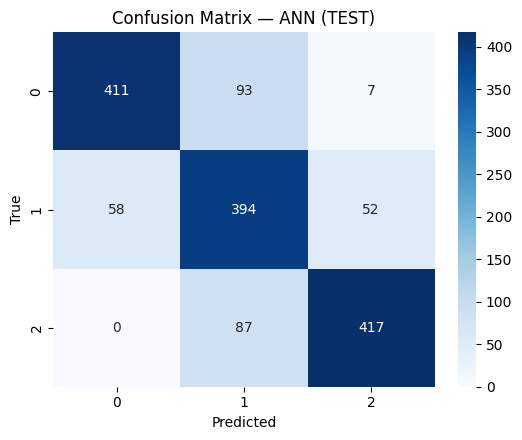


=== Recap ===
{
  "n_samples": 7592,
  "n_features_numeric": 7,
  "n_features_categorical": 8,
  "train_tertiles": {
    "q33": 1.800064,
    "q66": 5.584
  },
  "class_dist_train": {
    "0": 2042,
    "2": 2046,
    "1": 1985
  },
  "best_cv_baseline": 0.9970354099294243,
  "ann_cv_acc": 0.8068525637114325
}


In [2]:
# === End-to-end: OHE categoricals + scaled numerics; baselines, ANN CV, final test ===
import warnings, math, json
warnings.filterwarnings("ignore")

# --- Core libs
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter

# --- Display
from IPython.display import display

# --- Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, make_scorer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_class_weight

# --- ANN (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# --- (Optional) Keras Tuner if available
try:
    import keras_tuner as kt
    HAS_TUNER = True
except Exception:
    HAS_TUNER = False

# ------------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# ------------------------------------------------------------------
# 1) Load data (Demand.csv only) and clean
# ------------------------------------------------------------------
DEMAND_CSV = "/Users/yaeesh/hev-spareparts-ml/data/Demand.csv"
df = pd.read_csv(DEMAND_CSV)
df.columns = df.columns.str.strip()
df["demand"] = pd.to_numeric(df["demand"], errors="coerce")
n0 = len(df)
df = df.dropna(subset=["demand"]).drop_duplicates().reset_index(drop=True)

print(f"Shape after cleaning: {df.shape}")
display(df.head(3))

# ------------------------------------------------------------------
# 2) Declare categorical vs numeric features (from your schema)
# ------------------------------------------------------------------
cat_cols = [
    "car type","made in","part","original/imitator","new\\used",
    "selling location","service location (repair shop/automotive company","critically"
]
num_cols = [
    "number of cars in jordan","car age","failure rate","price of the car",
    "repair or replacement cost","car total maintenance cost average","on line price"
]

# sanity: ensure all expected columns exist
missing_cols = [c for c in (cat_cols + num_cols + ["demand"]) if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"

# ------------------------------------------------------------------
# 3) Split first (stratify by tertiles on full), then compute tertiles on TRAIN ONLY
#    -> prevents leakage from test into bin thresholds
# ------------------------------------------------------------------
strata_all = pd.qcut(df["demand"], q=3, labels=False, duplicates="drop")
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=strata_all
)

q33, q66 = train_df["demand"].quantile([0.33, 0.66])

def to_tertile_classes(s, q33, q66):
    return pd.cut(s, bins=[-np.inf, q33, q66, np.inf], labels=[0,1,2]).astype(int)

train_df["demand_class"] = to_tertile_classes(train_df["demand"], q33, q66)
test_df["demand_class"]  = to_tertile_classes(test_df["demand"],  q33, q66)

X_train = train_df[cat_cols + num_cols].copy()
y_train = train_df["demand_class"].copy()
X_test  = test_df[cat_cols + num_cols].copy()
y_test  = test_df["demand_class"].copy()

print(f"Split shapes: X_train {X_train.shape}  X_test {X_test.shape} | y_train {y_train.shape} y_test {y_test.shape}")
print("Class distribution (train):", dict(Counter(y_train)))

# ------------------------------------------------------------------
# 4) Preprocessing: OHE for categoricals, StandardScaler for numerics
#    (fit on TRAIN only inside each pipeline / fold)
# ------------------------------------------------------------------
def make_preproc():
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
        ("num", StandardScaler(), num_cols),
    ])

macro_f1 = make_scorer(f1_score, average="macro")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_eval(model):
    pipe = Pipeline([("preproc", make_preproc()), ("clf", model)])
    acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    f1m = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=macro_f1)
    return acc.mean(), acc.std(), f1m.mean(), f1m.std()

# ------------------------------------------------------------------
# 5) Classic ML baselines (leak-safe CV + held-out test)
# ------------------------------------------------------------------
models = {
    "LogReg": LogisticRegression(max_iter=2000),
    "SVM (RBF)": SVC(kernel="rbf", probability=False),
    "KNN(7)": KNeighborsClassifier(n_neighbors=7),
    "RandomForest": RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

rows = []
for name, mdl in models.items():
    am, as_, fm, fs = cv_eval(mdl)
    rows.append({"Model": name, "CV_Acc_mean": am, "CV_Acc_std": as_, "CV_F1_macro_mean": fm, "CV_F1_macro_std": fs})
baseline_df = pd.DataFrame(rows).sort_values("CV_Acc_mean", ascending=False)

print("\n=== Classic ML baselines (5-fold CV, OHE+scale inside folds) ===")
display(baseline_df)

if (baseline_df["CV_Acc_mean"] >= 0.98).any():
    print("\nNOTE: One or more models show ~98%+ CV accuracy. Double-check data collection; "
          "it may be genuinely easy for trees, but confirm there isn’t a hidden proxy.")

# Fit best tree models on TRAIN and evaluate on TEST
for name in ["RandomForest", "GradientBoosting"]:
    pipe = Pipeline([("preproc", make_preproc()), ("clf", models[name])])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"\n{name} — Held-out TEST")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, digits=3))

# ------------------------------------------------------------------
# 6) ANN cross-validation on transformed matrix (OHE+scaled numerics)
#    - Fit preprocessor on TRAIN only
#    - Inside each fold, re-fit scaler/OHE on fold-train to avoid leakage
# ------------------------------------------------------------------
def build_ann(input_dim, n_classes=3, width=128, drop=0.2, lr=3e-4):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(width, activation="relu"),
        Dropout(drop),
        Dense(width//2, activation="relu"),
        Dropout(drop/2),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer=Adam(learning_rate=lr),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

# Prepare a single preprocessor to transform the full TRAIN for final fit later
preproc_full = make_preproc()
X_train_t = preproc_full.fit_transform(X_train)  # fit on TRAIN
X_test_t  = preproc_full.transform(X_test)

ann_accs, ann_f1s = [], []
for fold, (tr, te) in enumerate(cv.split(X_train, y_train), start=1):
    # fit a fresh preproc per fold to avoid leakage
    preproc_fold = make_preproc()
    X_tr = preproc_fold.fit_transform(X_train.iloc[tr])
    X_te = preproc_fold.transform(X_train.iloc[te])
    y_tr = y_train.iloc[tr].values
    y_te = y_train.iloc[te].values

    # class weights (balanced)
    classes = np.unique(y_tr)
    cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_tr)
    cw = {int(c): float(w) for c, w in zip(classes, cw)}

    ann = build_ann(input_dim=X_tr.shape[1], n_classes=len(classes))
    es = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)
    ann.fit(X_tr, y_tr, validation_data=(X_te, y_te),
            epochs=200, batch_size=128, verbose=0, callbacks=[es], class_weight=cw)

    y_hat = np.argmax(ann.predict(X_te, verbose=0), axis=1)
    ann_accs.append(accuracy_score(y_te, y_hat))
    ann_f1s.append(f1_score(y_te, y_hat, average="macro"))

ann_cv = {
    "ANN_CV_Acc_mean": float(np.mean(ann_accs)),
    "ANN_CV_Acc_std": float(np.std(ann_accs)),
    "ANN_CV_F1_macro_mean": float(np.mean(ann_f1s)),
    "ANN_CV_F1_macro_std": float(np.std(ann_f1s)),
}
print("\n=== ANN (5-fold CV on OHE+scaled) ===")
display(pd.DataFrame([ann_cv]))

# ------------------------------------------------------------------
# 7) (Optional) Hyperparameter search with Keras Tuner on transformed TRAIN
# ------------------------------------------------------------------
best_cfg = {"width": 128, "drop": 0.2, "lr": 3e-4}
if HAS_TUNER:
    class ANNHyper(kt.HyperModel):
        def __init__(self, input_dim, n_classes=3):
            self.input_dim = input_dim
            self.n_classes = n_classes
        def build(self, hp):
            width = hp.Int("width", min_value=64, max_value=256, step=32, default=128)
            drop  = hp.Float("dropout", min_value=0.0, max_value=0.5, step=0.1, default=0.2)
            lr    = hp.Float("lr", min_value=1e-4, max_value=5e-3, sampling="log", default=3e-4)
            m = Sequential([
                Input(shape=(self.input_dim,)),
                Dense(width, activation="relu"),
                Dropout(drop),
                Dense(width//2, activation="relu"),
                Dropout(drop/2),
                Dense(self.n_classes, activation="softmax"),
            ])
            m.compile(optimizer=Adam(learning_rate=lr),
                      loss="sparse_categorical_crossentropy",
                      metrics=["accuracy"])
            return m

    tuner = kt.RandomSearch(
        ANNHyper(input_dim=X_train_t.shape[1], n_classes=3),
        objective="val_accuracy",
        max_trials=10,
        executions_per_trial=1,
        directory="tuner_tmp",
        project_name="ann_ohe_scaled",
        overwrite=True,
        seed=RANDOM_STATE
    )
    es_t = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    tuner.search(X_train_t, y_train.values, validation_split=0.2, epochs=100, batch_size=128, callbacks=[es_t], verbose=0)
    best = tuner.get_best_hyperparameters(1)[0]
    best_cfg = {
        "width": int(best.get("width")),
        "drop": float(best.get("dropout")),
        "lr":   float(best.get("lr")),
    }
    print("\nBest ANN hyperparams (tuner):", best_cfg)

# ------------------------------------------------------------------
# 8) Final ANN fit on full TRAIN (transformed), evaluate on TEST
# ------------------------------------------------------------------
classes = np.unique(y_train)
cw = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
cw = {int(c): float(w) for c, w in zip(classes, cw)}

final_ann = Sequential([
    Input(shape=(X_train_t.shape[1],)),
    Dense(best_cfg["width"], activation="relu"),
    Dropout(best_cfg["drop"]),
    Dense(best_cfg["width"]//2, activation="relu"),
    Dropout(best_cfg["drop"]/2),
    Dense(len(classes), activation="softmax"),
])
final_ann.compile(optimizer=Adam(learning_rate=best_cfg["lr"]),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

es_final = EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True)
hist = final_ann.fit(X_train_t, y_train.values, validation_split=0.2, epochs=200,
                     batch_size=128, verbose=0, callbacks=[es_final], class_weight=cw)

y_pred_test = np.argmax(final_ann.predict(X_test_t, verbose=0), axis=1)
print("\n=== ANN — Held-out TEST ===")
print(classification_report(y_test, y_pred_test, digits=3))

# (Optional) small confusion matrix plot
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred_test, labels=[0,1,2])
plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2], yticklabels=[0,1,2])
plt.title("Confusion Matrix — ANN (TEST)")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()

# ------------------------------------------------------------------
# 9) Tiny sanity recap
# ------------------------------------------------------------------
recap = {
    "n_samples": int(len(df)),
    "n_features_numeric": len(num_cols),
    "n_features_categorical": len(cat_cols),
    "train_tertiles": {"q33": float(q33), "q66": float(q66)},
    "class_dist_train": {int(k): int(v) for k, v in Counter(y_train).items()},
    "best_cv_baseline": float(baseline_df.iloc[0]["CV_Acc_mean"]),
    "ann_cv_acc": float(np.mean(ann_accs)),
}
print("\n=== Recap ===")
print(json.dumps(recap, indent=2))


# Same script as 93% but treating the maintenance cost as continuous

Initial shape: (7652, 16)
Dropping 60 duplicate rows

Per-part purity, top 10:
part
2     1.000000
1     0.900000
29    0.829787
6     0.796748
24    0.739130
36    0.702128
18    0.659574
20    0.609524
10    0.608696
15    0.595745
dtype: float64
Mean per-part purity: 0.5293

Train-only thresholds: 33%=1.800064, 66%=5.589000

Class distribution (train):
demand
0    1917
1    1861
2    1942
Name: count, dtype: int64
Class distribution (test):
demand
0    636
1    632
2    604
Name: count, dtype: int64

Row-hash overlap between train and test using model features: 0 rows

Starting exhaustive grid search over 72 combinations...
Config 1/72: {'num_layers': 1, 'units': 16, 'dropout_rate': 0.0, 'l2_reg': 0.0, 'learning_rate': 0.001}
Config 2/72: {'num_layers': 1, 'units': 16, 'dropout_rate': 0.0, 'l2_reg': 0.0, 'learning_rate': 0.003}
Config 3/72: {'num_layers': 1, 'units': 16, 'dropout_rate': 0.0, 'l2_reg': 0.0, 'learning_rate': 0.01}
Config 4/72: {'num_layers': 1, 'units': 16, 'dropout_r

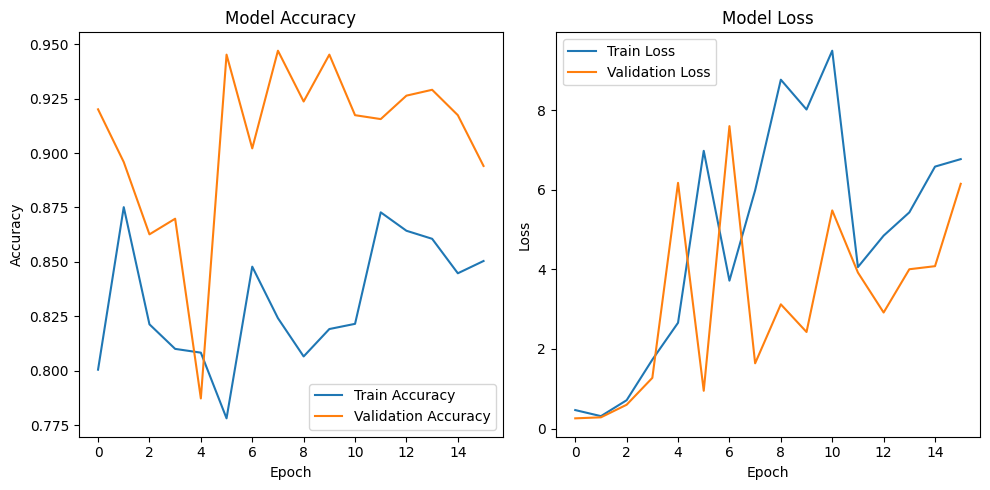

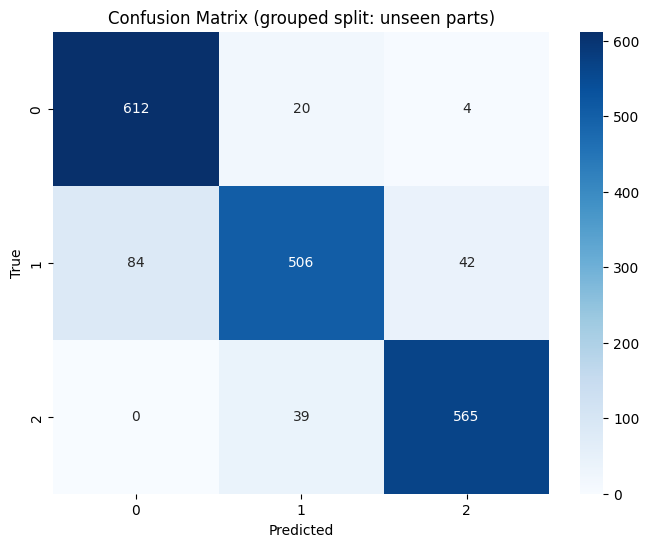


Classification Report (grouped split: unseen parts):
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       636
           1       0.90      0.80      0.85       632
           2       0.92      0.94      0.93       604

    accuracy                           0.90      1872
   macro avg       0.90      0.90      0.90      1872
weighted avg       0.90      0.90      0.90      1872

Test Accuracy: 0.8990
Macro F1:      0.8981
Fold 1: Acc=87.52% | Loss=0.2953 | MacroF1=0.8765
Fold 2: Acc=86.80% | Loss=0.3356 | MacroF1=0.8544
Fold 3: Acc=87.67% | Loss=0.2855 | MacroF1=0.8774
Fold 4: Acc=89.20% | Loss=0.2779 | MacroF1=0.8939
Fold 5: Acc=90.70% | Loss=0.2513 | MacroF1=0.9045

------------------------------------------------------------------------
Grouped CV summary (unseen parts each fold):
Accuracy: mean 88.38%  (± 1.40)
Macro F1: mean 0.8814 (± 0.0171)
Loss:     mean 0.2891
-----------------------------------------------------------------

In [3]:
# ===================== Imports & Reproducibility =====================
import warnings
warnings.filterwarnings('ignore')

import os
import random
import itertools
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score, f1_score
)
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ===================== Config =====================
# Exclude 'part' from features (still used for grouping)
DROP_PART = True

# Grid for exhaustive search
GRID = {
    'num_layers':    [1, 2, 3],
    'units':         [16, 32],
    'dropout_rate':  [0.0, 0.2],
    'l2_reg':        [0.0, 1e-4],
    'learning_rate': [1e-3, 3e-3, 1e-2]
}

# File path
file_path = r"/Users/yaeesh/Downloads/A Systematic AI-based Paradigm for Classifying Hybrid Electric Vehicle Spare Parts Using Their Price and Demand/Demand.csv"

# ===================== Load & clean =====================
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
print("Initial shape:", df.shape)

# Drop exact duplicates
dup_count = df.duplicated().sum()
if dup_count:
    print(f"Dropping {dup_count} duplicate rows")
    df = df.drop_duplicates().reset_index(drop=True)

# ===================== Feature schema =====================
# CHANGED: 'car total maintenance cost average' moved to numeric
cat_cols = [
    'car type',
    'made in',
    'original/imitator',
    'new\\used',
    'selling location',
    'service location (repair shop/automotive company',
    'part'  # identity-like
]

num_all = [
    'number of cars in jordan',
    'car age',
    'failure rate',
    'price of the car',
    'repair or replacement cost',
    'critically',
    'on line price',
    'car total maintenance cost average'   # <-- moved here (numeric)
]

missing_cols = [c for c in cat_cols + num_all + ['demand'] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

cat_cols_effective = [c for c in cat_cols if not (DROP_PART and c == 'part')]
X_all = df[cat_cols_effective + num_all].copy()
groups_all = df['part'].astype(str)  # for grouped splits

# For numeric transforms
skewed_cols = [
    'on line price',
    'number of cars in jordan',
    'failure rate',
    'repair or replacement cost',
    'critically',
    'price of the car'
    # (we're NOT altering skew treatment beyond the requested change)
]
other_num_cols = [c for c in num_all if c not in skewed_cols]

# ===================== Helper functions =====================
def compute_thresholds_from_train(demand_series, q_low=0.33, q_high=0.66):
    q = demand_series.quantile([q_low, q_high])
    return float(q.loc[q_low]), float(q.loc[q_high])

def bin_with_thresholds(demand_series, low_thr, high_thr):
    return pd.cut(demand_series,
                  bins=[-np.inf, low_thr, high_thr, np.inf],
                  labels=[0, 1, 2]).astype(int)

def make_preprocessor():
    numeric_skew_pipeline = Pipeline(steps=[
        ('log1p', FunctionTransformer(np.log1p, validate=False)),
        ('scaler', StandardScaler())
    ])
    numeric_pipeline = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    # Version-compatible OneHotEncoder
    try:
        categorical_pipeline = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        categorical_pipeline = OneHotEncoder(handle_unknown='ignore', sparse=False)

    return ColumnTransformer(
        transformers=[
            ('num_skew', numeric_skew_pipeline, skewed_cols),
            ('num',     numeric_pipeline,       other_num_cols),
            ('cat',     categorical_pipeline,   cat_cols_effective)
        ],
        remainder='drop'
    )

def build_model(input_dim, num_layers, units, dropout_rate, l2_reg, learning_rate, num_classes=3):
    model = Sequential()
    reg = regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None
    for i in range(num_layers):
        if i == 0:
            model.add(Dense(units, activation='relu', kernel_regularizer=reg, input_shape=(input_dim,)))
        else:
            model.add(Dense(units, activation='relu', kernel_regularizer=reg))
        if dropout_rate and dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def grid_combinations(grid_dict):
    keys = list(grid_dict.keys())
    for values in itertools.product(*(grid_dict[k] for k in keys)):
        yield dict(zip(keys, values))

def hash_rows(df_like):
    """Create a stable hash per row using the actual feature columns used by the model."""
    str_df = df_like.copy()
    for c in str_df.columns:
        if pd.api.types.is_float_dtype(str_df[c]) or pd.api.types.is_integer_dtype(str_df[c]):
            str_df[c] = str_df[c].astype(float).map(lambda x: f"{x:.12g}")
        else:
            str_df[c] = str_df[c].astype(str)
    concat = str_df.apply(lambda r: '||'.join(r.values.astype(str)), axis=1)
    return concat.map(lambda s: hashlib.md5(s.encode('utf-8')).hexdigest())

# ===================== Per-part purity (leakage hint) =====================
tmp_low, tmp_high = compute_thresholds_from_train(df['demand'])  # approximate
tmp_y = bin_with_thresholds(df['demand'], tmp_low, tmp_high)
part_class_counts = pd.crosstab(df['part'], tmp_y)
part_purity = part_class_counts.max(axis=1) / part_class_counts.sum(axis=1)
print("\nPer-part purity, top 10:")
print(part_purity.sort_values(ascending=False).head(10))
print(f"Mean per-part purity: {part_purity.mean():.4f}")

# ===================== Outer grouped train/test split =====================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X_all, None, groups=groups_all))

X_train_raw, X_test_raw = X_all.iloc[train_idx], X_all.iloc[test_idx]
groups_train, groups_test = groups_all.iloc[train_idx], groups_all.iloc[test_idx]
demand_train, demand_test = df['demand'].iloc[train_idx], df['demand'].iloc[test_idx]

# Create labels using thresholds from TRAIN ONLY
low_thr, high_thr = compute_thresholds_from_train(demand_train)
print(f"\nTrain-only thresholds: 33%={low_thr:.6f}, 66%={high_thr:.6f}")
y_train = bin_with_thresholds(demand_train, low_thr, high_thr)
y_test  = bin_with_thresholds(demand_test,  low_thr, high_thr)

# Class distribution check
print("\nClass distribution (train):")
print(y_train.value_counts().sort_index())
print("Class distribution (test):")
print(y_test.value_counts().sort_index())

# ===================== Row-hash overlap audit =====================
train_hash = hash_rows(X_train_raw)
test_hash  = hash_rows(X_test_raw)
overlap = set(train_hash).intersection(set(test_hash))
print(f"\nRow-hash overlap between train and test using model features: {len(overlap)} rows")
if len(overlap) > 0:
    print("WARNING: Identical feature rows detected across train and test. Investigate potential duplicates.")

# ===================== Exhaustive grid search with grouped inner validation =====================
inner_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
inner_tr_idx, inner_val_idx = next(inner_gss.split(X_train_raw, y_train, groups=groups_train))
X_inner_tr_raw = X_train_raw.iloc[inner_tr_idx]
X_inner_val_raw = X_train_raw.iloc[inner_val_idx]
y_inner_tr = y_train.iloc[inner_tr_idx]
y_inner_val = y_train.iloc[inner_val_idx]

def fit_transform_preprocessor(X_tr_raw, X_val_raw):
    pre = make_preprocessor()
    X_tr = pre.fit_transform(X_tr_raw)
    X_val = pre.transform(X_val_raw)
    return pre, X_tr, X_val

best_cfg = None
best_val_f1 = -np.inf
best_model = None
best_history = None

total_combos = int(np.prod([len(v) for v in GRID.values()]))
print(f"\nStarting exhaustive grid search over {total_combos} combinations...")
for idx, cfg in enumerate(grid_combinations(GRID), start=1):
    print(f"Config {idx}/{total_combos}: {cfg}")
    pre_gs, X_inner_tr, X_inner_val = fit_transform_preprocessor(X_inner_tr_raw, X_inner_val_raw)
    input_dim = X_inner_tr.shape[1]

    model = build_model(
        input_dim=input_dim,
        num_layers=cfg['num_layers'],
        units=cfg['units'],
        dropout_rate=cfg['dropout_rate'],
        l2_reg=cfg['l2_reg'],
        learning_rate=cfg['learning_rate'],
        num_classes=3
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)

    history = model.fit(
        X_inner_tr, y_inner_tr,
        epochs=200,
        validation_data=(X_inner_val, y_inner_val),
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    y_val_pred = np.argmax(model.predict(X_inner_val, verbose=0), axis=1)
    f1 = f1_score(y_inner_val, y_val_pred, average='macro')
    if f1 > best_val_f1:
        best_val_f1 = f1
        best_cfg = cfg
        best_model = model
        best_history = history
        best_preprocessor = pre_gs

print("\nBest grid configuration (inner grouped val macro F1):", round(best_val_f1, 4))
print(best_cfg)

# ===================== Retrain on full training set, with grouped inner val =====================
preprocessor_full = make_preprocessor()
X_train_proc = preprocessor_full.fit_transform(X_train_raw)
X_test_proc  = preprocessor_full.transform(X_test_raw)
input_dim = X_train_proc.shape[1]

inner_tr_idx2, inner_val_idx2 = next(inner_gss.split(X_train_raw, y_train, groups=groups_train))
X_tr2_raw, X_val2_raw = X_train_raw.iloc[inner_tr_idx2], X_train_raw.iloc[inner_val_idx2]
y_tr2, y_val2 = y_train.iloc[inner_tr_idx2], y_train.iloc[inner_val_idx2]
pre_ep = make_preprocessor()
X_tr2 = pre_ep.fit_transform(X_tr2_raw)
X_val2 = pre_ep.transform(X_val2_raw)

model = build_model(
    input_dim=input_dim,
    num_layers=best_cfg['num_layers'],
    units=best_cfg['units'],
    dropout_rate=best_cfg['dropout_rate'],
    l2_reg=best_cfg['l2_reg'],
    learning_rate=best_cfg['learning_rate'],
    num_classes=3
)

early_stop_final = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_final  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)

history = model.fit(
    X_tr2, y_tr2,
    epochs=200,
    validation_data=(X_val2, y_val2),
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=0
)

# ===================== Plots =====================
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.savefig('training_validation_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ===================== Test evaluation (unseen parts) =====================
y_pred_proba = model.predict(X_test_proc, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test.to_numpy()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.title('Confusion Matrix (grouped split: unseen parts)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClassification Report (grouped split: unseen parts):")
print(classification_report(y_true, y_pred))
print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1:      {f1_score(y_true, y_pred, average='macro'):.4f}")

# ===================== Grouped CV with per-fold thresholds & preprocessing =====================
num_folds = 5
gkf = GroupKFold(n_splits=num_folds)

acc_per_fold, f1_per_fold, loss_per_fold = [], [], []
fold_no = 1
for tr_idx, val_idx in gkf.split(X_all, None, groups=groups_all):
    X_tr_raw, X_val_raw = X_all.iloc[tr_idx], X_all.iloc[val_idx]
    demand_tr, demand_val = df['demand'].iloc[tr_idx], df['demand'].iloc[val_idx]

    # Fold-specific thresholds from training portion
    low_f, high_f = compute_thresholds_from_train(demand_tr)
    y_tr_f = bin_with_thresholds(demand_tr, low_f, high_f)
    y_val_f = bin_with_thresholds(demand_val, low_f, high_f)

    pre_fold = make_preprocessor()
    X_tr = pre_fold.fit_transform(X_tr_raw)
    X_val = pre_fold.transform(X_val_raw)

    model_fold = build_model(
        input_dim=X_tr.shape[1],
        num_layers=best_cfg['num_layers'],
        units=best_cfg['units'],
        dropout_rate=best_cfg['dropout_rate'],
        l2_reg=best_cfg['l2_reg'],
        learning_rate=best_cfg['learning_rate'],
        num_classes=3
    )

    hist_f = model_fold.fit(
        X_tr, y_tr_f,
        epochs=200,
        validation_data=(X_val, y_val_f),
        callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
                   ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)],
        verbose=0
    )

    loss, acc = model_fold.evaluate(X_val, y_val_f, verbose=0)
    y_val_pred = np.argmax(model_fold.predict(X_val, verbose=0), axis=1)
    f1 = f1_score(y_val_f, y_val_pred, average='macro')

    print(f"Fold {fold_no}: Acc={acc*100:.2f}% | Loss={loss:.4f} | MacroF1={f1:.4f}")
    acc_per_fold.append(acc * 100); f1_per_fold.append(f1); loss_per_fold.append(loss)
    fold_no += 1

print('\n' + '-'*72)
print('Grouped CV summary (unseen parts each fold):')
print(f"Accuracy: mean {np.mean(acc_per_fold):.2f}%  (± {np.std(acc_per_fold):.2f})")
print(f"Macro F1: mean {np.mean(f1_per_fold):.4f} (± {np.std(f1_per_fold):.4f})")
print(f"Loss:     mean {np.mean(loss_per_fold):.4f}")
print('-'*72)

# ===================== Single-feature leakage audit (grouped CV) =====================
def single_feature_cv_score(feature_name):
    # Build a tiny pipeline: transform only this feature, then multinomial logistic regression
    if feature_name in cat_cols_effective:
        try:
            ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
        pipe = Pipeline([('ohe', ohe),
                         ('clf', LogisticRegression(max_iter=2000, multi_class='multinomial'))])
        X_feat = df[[feature_name]].astype(str)
    else:
        # numeric
        steps = []
        if feature_name in skewed_cols:
            steps.append(('log1p', FunctionTransformer(np.log1p, validate=False)))
        steps.append(('scaler', StandardScaler()))
        steps.append(('clf', LogisticRegression(max_iter=2000, multi_class='multinomial')))
        pipe = Pipeline(steps)
        X_feat = df[[feature_name]].copy()

    f1_scores = []
    for tr_idx, val_idx in gkf.split(X_all, None, groups=groups_all):
        d_tr = df['demand'].iloc[tr_idx]; d_val = df['demand'].iloc[val_idx]
        low_f, high_f = compute_thresholds_from_train(d_tr)
        y_tr_f = bin_with_thresholds(d_tr, low_f, high_f)
        y_val_f = bin_with_thresholds(d_val, low_f, high_f)

        X_tr_f = X_feat.iloc[tr_idx]; X_val_f = X_feat.iloc[val_idx]
        pipe.fit(X_tr_f, y_tr_f)
        y_val_pred = pipe.predict(X_val_f)
        f1_scores.append(f1_score(y_val_f, y_val_pred, average='macro'))

    return np.mean(f1_scores)

features_to_audit = cat_cols_effective + num_all
audit_results = []
print("\nRunning single-feature leakage audit (grouped CV, macro F1 per feature)...")
for feat in features_to_audit:
    score = single_feature_cv_score(feat)
    audit_results.append((feat, score))
audit_results.sort(key=lambda x: x[1], reverse=True)
print("Top 10 features by single-feature macro F1:")
for name, sc in audit_results[:10]:
    print(f"{name:45s} {sc:.4f}")

suspicious = [(n, s) for n, s in audit_results if s >= 0.99]
if suspicious:
    print("\nWARNING: These features alone achieve near-perfect classification under grouped CV:")
    for n, s in suspicious:
        print(f"  - {n}: macro F1 {s:.4f}")
    print("Review whether they encode target information directly or leak future knowledge.")

# ===================== Save tuned model & thresholds =====================
model.save("demand_clf.keras")
with open("label_thresholds.txt", "w") as f:
    f.write(f"{low_thr},{high_thr}\n")
print("\nSaved tuned model to demand_clf.keras")
print("Saved train-only label thresholds to label_thresholds.txt")
print("Best configuration:", GRID if best_cfg is None else best_cfg)


Initial shape: (7652, 16)
Dropped 0 rows with non-numeric demand
Dropping 60 duplicate rows
Shape after cleaning: (7592, 16)


,car type,made in,number of cars in jordan,car age,part,failure rate,price of the car,original/imitator,new\used,selling location,service location (repair shop/automotive company,repair or replacement cost,car total maintenance cost average,critically,on line price,demand
0,4,1,1841,4,9,0.263158,15000.0,1,0,1,1,10,8200,0.0600,20.00,4.844737
1,2,3,686,1,12,0.089600,19500.0,1,1,3,2,30,9100,0.1297,71.00,0.614656
2,1,2,1924,12,24,0.086200,8700.0,1,0,1,1,10,5500,0.1275,56.08,1.658488



Per-part purity, top 10:
part
2     1.000000
1     0.900000
29    0.829787
6     0.796748
24    0.739130
36    0.702128
18    0.659574
20    0.609524
10    0.608696
15    0.595745
dtype: float64
Mean per-part purity: 0.5293

Train-only thresholds: 33%=1.800064, 66%=5.589000

Class distribution (train):
demand
0    1917
1    1861
2    1942
Name: count, dtype: int64
Class distribution (test):
demand
0    636
1    632
2    604
Name: count, dtype: int64

Row-hash overlap between train and test using model features: 0 rows

Starting exhaustive grid search over 72 combinations...
Config 1/72: {'num_layers': 1, 'units': 16, 'dropout_rate': 0.0, 'l2_reg': 0.0, 'learning_rate': 0.001}
Config 2/72: {'num_layers': 1, 'units': 16, 'dropout_rate': 0.0, 'l2_reg': 0.0, 'learning_rate': 0.003}
Config 3/72: {'num_layers': 1, 'units': 16, 'dropout_rate': 0.0, 'l2_reg': 0.0, 'learning_rate': 0.01}
Config 4/72: {'num_layers': 1, 'units': 16, 'dropout_rate': 0.0, 'l2_reg': 0.0001, 'learning_rate': 0.001}


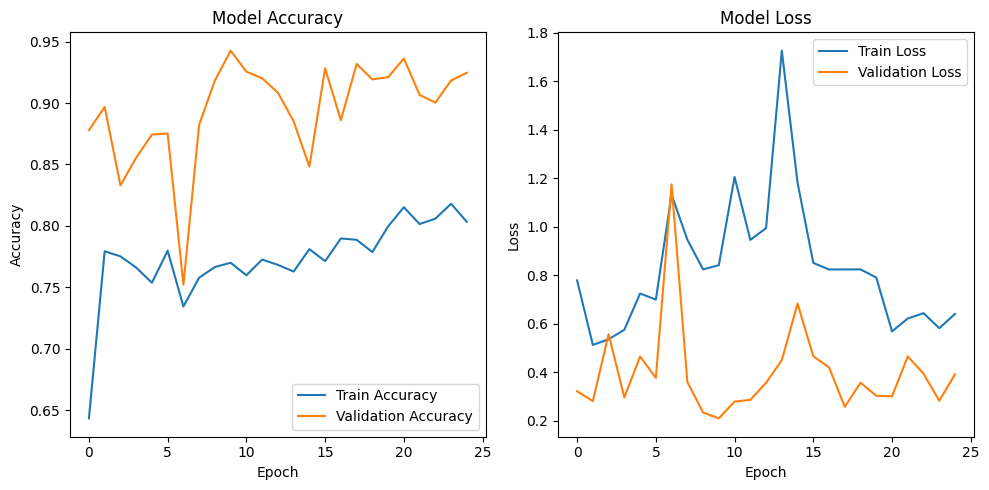

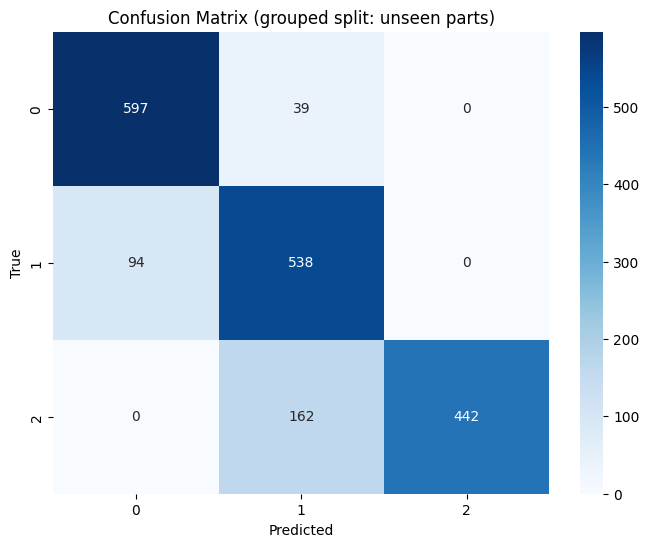


Classification Report (grouped split: unseen parts):
              precision    recall  f1-score   support

           0      0.864     0.939     0.900       636
           1      0.728     0.851     0.785       632
           2      1.000     0.732     0.845       604

    accuracy                          0.842      1872
   macro avg      0.864     0.841     0.843      1872
weighted avg      0.862     0.842     0.843      1872

Test Accuracy: 0.8424
Macro F1:      0.8432
Fold 1: Acc=92.38% | Loss=0.2881 | MacroF1=0.9237
Fold 2: Acc=85.63% | Loss=0.3345 | MacroF1=0.8421
Fold 3: Acc=89.06% | Loss=0.3305 | MacroF1=0.8914
Fold 4: Acc=88.01% | Loss=0.3061 | MacroF1=0.8746
Fold 5: Acc=88.25% | Loss=0.3240 | MacroF1=0.8794

------------------------------------------------------------------------
Grouped CV summary (unseen parts each fold):
Accuracy: mean 88.67%  (± 2.18)
Macro F1: mean 0.8822 (± 0.0264)
Loss:     mean 0.3166
-----------------------------------------------------------------

In [4]:
# ===================== Imports & Reproducibility =====================
import warnings
warnings.filterwarnings('ignore')

import os
import random
import itertools
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ===================== Config =====================
# Exclude 'part' from features (still used for grouping)
DROP_PART = True

# Grid for exhaustive search (72 combos)
GRID = {
    'num_layers':    [1, 2, 3],
    'units':         [16, 32],
    'dropout_rate':  [0.0, 0.2],
    'l2_reg':        [0.0, 1e-4],
    'learning_rate': [1e-3, 3e-3, 1e-2]
}

# Flip to True if you want to save artifacts at the end
SAVE_ARTIFACTS = False

# File path (update if needed)
file_path = r"/Users/yaeesh/Downloads/A Systematic AI-based Paradigm for Classifying Hybrid Electric Vehicle Spare Parts Using Their Price and Demand/Demand.csv"

# ===================== Load & clean =====================
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
print("Initial shape:", df.shape)

# Make sure demand is numeric
df['demand'] = pd.to_numeric(df['demand'], errors='coerce')
n_before = len(df)
df = df.dropna(subset=['demand']).reset_index(drop=True)
print(f"Dropped {n_before - len(df)} rows with non-numeric demand")

# Drop exact duplicates (all columns)
dup_count = df.duplicated().sum()
if dup_count:
    print(f"Dropping {dup_count} duplicate rows")
    df = df.drop_duplicates().reset_index(drop=True)

print("Shape after cleaning:", df.shape)
display(df.head(3))

# ===================== Feature schema =====================
# CATEGORICAL (kept as categorical) — NOTE: 'part' is only for grouping, not a feature
cat_cols = [
    'car type',
    'made in',
    'original/imitator',
    'new\\used',
    'selling location',
    'service location (repair shop/automotive company',
    'part'  # identity-like; will be dropped from features if DROP_PART=True
]

# NUMERIC (includes 'car total maintenance cost average' as NUMERIC)
num_all = [
    'number of cars in jordan',
    'car age',
    'failure rate',
    'price of the car',
    'repair or replacement cost',
    'critically',
    'on line price',
    'car total maintenance cost average'   # <-- numeric, not categorical
]

# Sanity check columns
missing_cols = [c for c in cat_cols + num_all + ['demand'] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

# Effective categorical feature list (exclude 'part' from features if requested)
cat_cols_effective = [c for c in cat_cols if not (DROP_PART and c == 'part')]

# Feature frame used by the model (cat + num)
X_all = df[cat_cols_effective + num_all].copy()
# Group key (never fed as a feature)
groups_all = df['part'].astype(str)

# For numeric transforms: skewed vs other numerics
skewed_cols = [
    'on line price',
    'number of cars in jordan',
    'failure rate',
    'repair or replacement cost',
    'critically',
    'price of the car',
    'car total maintenance cost average',   # treat as skewed numeric -> log1p + scale
]
other_num_cols = [c for c in num_all if c not in skewed_cols]

# ===================== Helper functions =====================
def compute_thresholds_from_train(demand_series, q_low=0.33, q_high=0.66):
    q = demand_series.quantile([q_low, q_high])
    return float(q.loc[q_low]), float(q.loc[q_high])

def bin_with_thresholds(demand_series, low_thr, high_thr):
    return pd.cut(demand_series,
                  bins=[-np.inf, low_thr, high_thr, np.inf],
                  labels=[0, 1, 2]).astype(int)

def make_preprocessor():
    numeric_skew_pipeline = Pipeline(steps=[
        ('log1p', FunctionTransformer(np.log1p, validate=False)),
        ('scaler', StandardScaler())
    ])
    numeric_pipeline = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    # Version-compatible OneHotEncoder
    try:
        categorical_pipeline = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        categorical_pipeline = OneHotEncoder(handle_unknown='ignore', sparse=False)

    return ColumnTransformer(
        transformers=[
            ('num_skew', numeric_skew_pipeline, skewed_cols),
            ('num',     numeric_pipeline,       other_num_cols),
            ('cat',     categorical_pipeline,   cat_cols_effective)
        ],
        remainder='drop'
    )

def build_model(input_dim, num_layers, units, dropout_rate, l2_reg, learning_rate, num_classes=3):
    model = Sequential()
    reg = regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None
    for i in range(num_layers):
        if i == 0:
            model.add(Dense(units, activation='relu', kernel_regularizer=reg, input_shape=(input_dim,)))
        else:
            model.add(Dense(units, activation='relu', kernel_regularizer=reg))
        if dropout_rate and dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def grid_combinations(grid_dict):
    keys = list(grid_dict.keys())
    for values in itertools.product(*(grid_dict[k] for k in keys)):
        yield dict(zip(keys, values))

def hash_rows(df_like):
    """Stable hash per row using the actual feature columns used by the model."""
    str_df = df_like.copy()
    for c in str_df.columns:
        if pd.api.types.is_float_dtype(str_df[c]) or pd.api.types.is_integer_dtype(str_df[c]):
            str_df[c] = str_df[c].astype(float).map(lambda x: f"{x:.12g}")
        else:
            str_df[c] = str_df[c].astype(str)
    concat = str_df.apply(lambda r: '||'.join(r.values.astype(str)), axis=1)
    return concat.map(lambda s: hashlib.md5(s.encode('utf-8')).hexdigest())

# ===================== Per-part purity (diagnostic, not used for labels) =====================
tmp_low, tmp_high = compute_thresholds_from_train(df['demand'])
tmp_y = bin_with_thresholds(df['demand'], tmp_low, tmp_high)
part_class_counts = pd.crosstab(df['part'], tmp_y)
part_purity = part_class_counts.max(axis=1) / part_class_counts.sum(axis=1)
print("\nPer-part purity, top 10:")
print(part_purity.sort_values(ascending=False).head(10))
print(f"Mean per-part purity: {part_purity.mean():.4f}")

# ===================== Outer grouped train/test split (by 'part') =====================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X_all, None, groups=groups_all))

X_train_raw, X_test_raw = X_all.iloc[train_idx], X_all.iloc[test_idx]
groups_train, groups_test = groups_all.iloc[train_idx], groups_all.iloc[test_idx]
demand_train, demand_test = df['demand'].iloc[train_idx], df['demand'].iloc[test_idx]

# Create labels using thresholds from TRAIN ONLY
low_thr, high_thr = compute_thresholds_from_train(demand_train)
print(f"\nTrain-only thresholds: 33%={low_thr:.6f}, 66%={high_thr:.6f}")
y_train = bin_with_thresholds(demand_train, low_thr, high_thr)
y_test  = bin_with_thresholds(demand_test,  low_thr, high_thr)

# Class distribution check
print("\nClass distribution (train):")
print(y_train.value_counts().sort_index())
print("Class distribution (test):")
print(y_test.value_counts().sort_index())

# ===================== Row-hash overlap audit (exact feature duplicates across split) =====================
train_hash = hash_rows(X_train_raw)
test_hash  = hash_rows(X_test_raw)
overlap = set(train_hash).intersection(set(test_hash))
print(f"\nRow-hash overlap between train and test using model features: {len(overlap)} rows")
if len(overlap) > 0:
    print("WARNING: Identical feature rows detected across train and test. Investigate potential duplicates.")

# ===================== Exhaustive grid search with grouped inner validation =====================
# Grouped validation carve-out from training for model selection.
inner_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
inner_tr_idx, inner_val_idx = next(inner_gss.split(X_train_raw, y_train, groups=groups_train))
X_inner_tr_raw = X_train_raw.iloc[inner_tr_idx]
X_inner_val_raw = X_train_raw.iloc[inner_val_idx]
y_inner_tr = y_train.iloc[inner_tr_idx]
y_inner_val = y_train.iloc[inner_val_idx]

def fit_transform_preprocessor(X_tr_raw, X_val_raw):
    pre = make_preprocessor()
    X_tr = pre.fit_transform(X_tr_raw)
    X_val = pre.transform(X_val_raw)
    return pre, X_tr, X_val

best_cfg = None
best_val_f1 = -np.inf
best_model = None
best_history = None
best_preprocessor = None

total_combos = int(np.prod([len(v) for v in GRID.values()]))
print(f"\nStarting exhaustive grid search over {total_combos} combinations...")
for idx, cfg in enumerate(grid_combinations(GRID), start=1):
    print(f"Config {idx}/{total_combos}: {cfg}")
    pre_gs, X_inner_tr, X_inner_val = fit_transform_preprocessor(X_inner_tr_raw, X_inner_val_raw)
    input_dim = X_inner_tr.shape[1]

    model = build_model(
        input_dim=input_dim,
        num_layers=cfg['num_layers'],
        units=cfg['units'],
        dropout_rate=cfg['dropout_rate'],
        l2_reg=cfg['l2_reg'],
        learning_rate=cfg['learning_rate'],
        num_classes=3
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)

    history = model.fit(
        X_inner_tr, y_inner_tr,
        epochs=200,
        validation_data=(X_inner_val, y_inner_val),
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    y_val_pred = np.argmax(model.predict(X_inner_val, verbose=0), axis=1)
    f1 = f1_score(y_inner_val, y_val_pred, average='macro')
    if f1 > best_val_f1:
        best_val_f1 = f1
        best_cfg = cfg
        best_model = model
        best_history = history
        best_preprocessor = pre_gs

print("\nBest grid configuration (inner grouped val macro F1):", round(best_val_f1, 4))
print(best_cfg)

# ===================== Retrain for early stopping on a grouped holdout from training =====================
# Fresh preprocessor fitted on the full outer training set only
preprocessor_full = make_preprocessor()
X_train_proc = preprocessor_full.fit_transform(X_train_raw)
X_test_proc  = preprocessor_full.transform(X_test_raw)
input_dim = X_train_proc.shape[1]

# Build best model and carve a grouped validation from training for early stopping
inner_tr_idx2, inner_val_idx2 = next(inner_gss.split(X_train_raw, y_train, groups=groups_train))
X_tr2_raw, X_val2_raw = X_train_raw.iloc[inner_tr_idx2], X_train_raw.iloc[inner_val_idx2]
y_tr2, y_val2 = y_train.iloc[inner_tr_idx2], y_train.iloc[inner_val_idx2]
pre_ep = make_preprocessor()
X_tr2 = pre_ep.fit_transform(X_tr2_raw)
X_val2 = pre_ep.transform(X_val2_raw)

model = build_model(
    input_dim=input_dim,
    num_layers=best_cfg['num_layers'],
    units=best_cfg['units'],
    dropout_rate=best_cfg['dropout_rate'],
    l2_reg=best_cfg['l2_reg'],
    learning_rate=best_cfg['learning_rate'],
    num_classes=3
)

early_stop_final = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_final  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)

history = model.fit(
    X_tr2, y_tr2,
    epochs=200,
    validation_data=(X_val2, y_val2),
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=0
)

# ===================== Plots =====================
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()

# ===================== Test evaluation (unseen parts) =====================
y_pred_proba = model.predict(X_test_proc, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test.to_numpy()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.title('Confusion Matrix (grouped split: unseen parts)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

print("\nClassification Report (grouped split: unseen parts):")
print(classification_report(y_true, y_pred, digits=3))
print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1:      {f1_score(y_true, y_pred, average='macro'):.4f}")

# ===================== Grouped CV with per-fold thresholds & preprocessing =====================
num_folds = 5
gkf = GroupKFold(n_splits=num_folds)

acc_per_fold, f1_per_fold, loss_per_fold = [], [], []
fold_no = 1
for tr_idx, val_idx in gkf.split(X_all, None, groups=groups_all):
    X_tr_raw, X_val_raw = X_all.iloc[tr_idx], X_all.iloc[val_idx]
    demand_tr, demand_val = df['demand'].iloc[tr_idx], df['demand'].iloc[val_idx]

    # Fold-specific thresholds from training portion
    low_f, high_f = compute_thresholds_from_train(demand_tr)
    y_tr_f = bin_with_thresholds(demand_tr, low_f, high_f)
    y_val_f = bin_with_thresholds(demand_val, low_f, high_f)

    pre_fold = make_preprocessor()
    X_tr = pre_fold.fit_transform(X_tr_raw)
    X_val = pre_fold.transform(X_val_raw)

    model_fold = build_model(
        input_dim=X_tr.shape[1],
        num_layers=best_cfg['num_layers'],
        units=best_cfg['units'],
        dropout_rate=best_cfg['dropout_rate'],
        l2_reg=best_cfg['l2_reg'],
        learning_rate=best_cfg['learning_rate'],
        num_classes=3
    )

    hist_f = model_fold.fit(
        X_tr, y_tr_f,
        epochs=200,
        validation_data=(X_val, y_val_f),
        callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
                   ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)],
        verbose=0
    )

    loss, acc = model_fold.evaluate(X_val, y_val_f, verbose=0)
    y_val_pred = np.argmax(model_fold.predict(X_val, verbose=0), axis=1)
    f1 = f1_score(y_val_f, y_val_pred, average='macro')

    print(f"Fold {fold_no}: Acc={acc*100:.2f}% | Loss={loss:.4f} | MacroF1={f1:.4f}")
    acc_per_fold.append(acc * 100); f1_per_fold.append(f1); loss_per_fold.append(loss)
    fold_no += 1

print('\n' + '-'*72)
print('Grouped CV summary (unseen parts each fold):')
print(f"Accuracy: mean {np.mean(acc_per_fold):.2f}%  (± {np.std(acc_per_fold):.2f})")
print(f"Macro F1: mean {np.mean(f1_per_fold):.4f} (± {np.std(f1_per_fold):.4f})")
print(f"Loss:     mean {np.mean(loss_per_fold):.4f}")
print('-'*72)

# ===================== Single-feature leakage audit (grouped CV) =====================
def single_feature_cv_score(feature_name):
    # Build a tiny pipeline: transform only this feature, then multinomial logistic regression
    from sklearn.linear_model import LogisticRegression

    if feature_name in cat_cols_effective:
        try:
            ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
        pipe = Pipeline([('ohe', ohe),
                         ('clf', LogisticRegression(max_iter=2000, multi_class='multinomial'))])
        X_feat = df[[feature_name]].astype(str)
    else:
        # numeric
        steps = []
        if feature_name in skewed_cols:
            steps.append(('log1p', FunctionTransformer(np.log1p, validate=False)))
        steps.append(('scaler', StandardScaler()))
        steps.append(('clf', LogisticRegression(max_iter=2000, multi_class='multinomial')))
        pipe = Pipeline(steps)
        X_feat = df[[feature_name]].copy()

    f1_scores = []
    for tr_idx, val_idx in gkf.split(X_all, None, groups=groups_all):
        d_tr = df['demand'].iloc[tr_idx]; d_val = df['demand'].iloc[val_idx]
        low_f, high_f = compute_thresholds_from_train(d_tr)
        y_tr_f = bin_with_thresholds(d_tr, low_f, high_f)
        y_val_f = bin_with_thresholds(d_val, low_f, high_f)

        X_tr_f = X_feat.iloc[tr_idx]; X_val_f = X_feat.iloc[val_idx]
        pipe.fit(X_tr_f, y_tr_f)
        y_val_pred = pipe.predict(X_val_f)
        f1_scores.append(f1_score(y_val_f, y_val_pred, average='macro'))

    return np.mean(f1_scores)

features_to_audit = cat_cols_effective + num_all
audit_results = []
print("\nRunning single-feature leakage audit (grouped CV, macro F1 per feature)...")
for feat in features_to_audit:
    score = single_feature_cv_score(feat)
    audit_results.append((feat, score))
audit_results.sort(key=lambda x: x[1], reverse=True)
print("Top 10 features by single-feature macro F1:")
for name, sc in audit_results[:10]:
    print(f"{name:45s} {sc:.4f}")

# Flag suspicious features
suspicious = [(n, s) for n, s in audit_results if s >= 0.99]
if suspicious:
    print("\nWARNING: These features alone achieve near-perfect classification under grouped CV:")
    for n, s in suspicious:
        print(f"  - {n}: macro F1 {s:.4f}")
    print("Review whether they encode target information directly or leak future knowledge.")

# ===================== Optional: save tuned model & thresholds =====================
if SAVE_ARTIFACTS:
    model.save("demand_clf.keras")
    with open("label_thresholds.txt", "w") as f:
        f.write(f"{low_thr},{high_thr}\n")
    print("\nSaved tuned model to demand_clf.keras")
    print("Saved train-only label thresholds to label_thresholds.txt")
    print("Best configuration:", GRID if best_cfg is None else best_cfg)


# Coming back to the 0.93 accuracy

Initial shape: (7652, 16)
Dropping 60 duplicate rows

Per-part purity, top 10:
part
2     1.000000
1     0.900000
29    0.829787
6     0.796748
24    0.739130
36    0.702128
18    0.659574
20    0.609524
10    0.608696
15    0.595745
dtype: float64
Mean per-part purity: 0.5293

Train-only thresholds: 33%=1.800064, 66%=5.589000

Class distribution (train):
demand
0    1917
1    1861
2    1942
Name: count, dtype: int64
Class distribution (test):
demand
0    636
1    632
2    604
Name: count, dtype: int64

Row-hash overlap between train and test using model features: 0 rows

Starting exhaustive grid search over 72 combinations...
Config 1/72: {'num_layers': 1, 'units': 16, 'dropout_rate': 0.0, 'l2_reg': 0.0, 'learning_rate': 0.001}
Config 2/72: {'num_layers': 1, 'units': 16, 'dropout_rate': 0.0, 'l2_reg': 0.0, 'learning_rate': 0.003}
Config 3/72: {'num_layers': 1, 'units': 16, 'dropout_rate': 0.0, 'l2_reg': 0.0, 'learning_rate': 0.01}
Config 4/72: {'num_layers': 1, 'units': 16, 'dropout_r

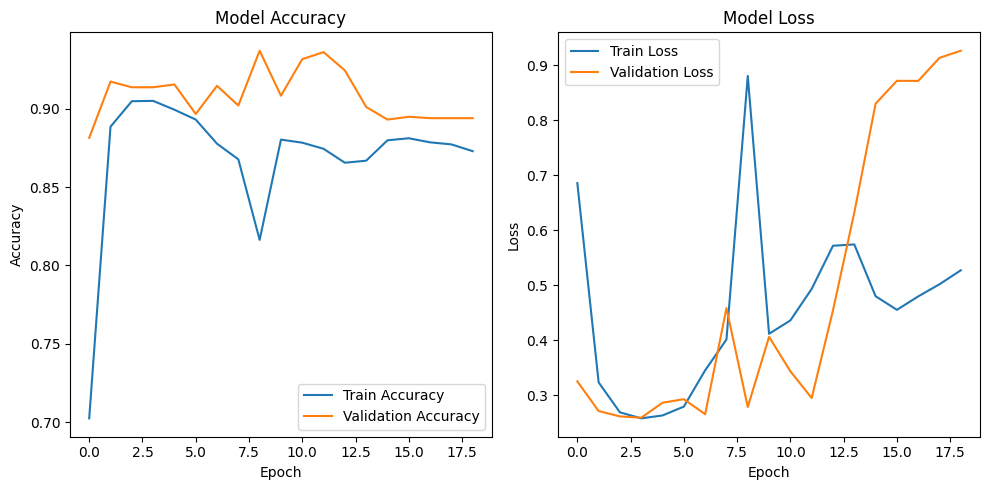

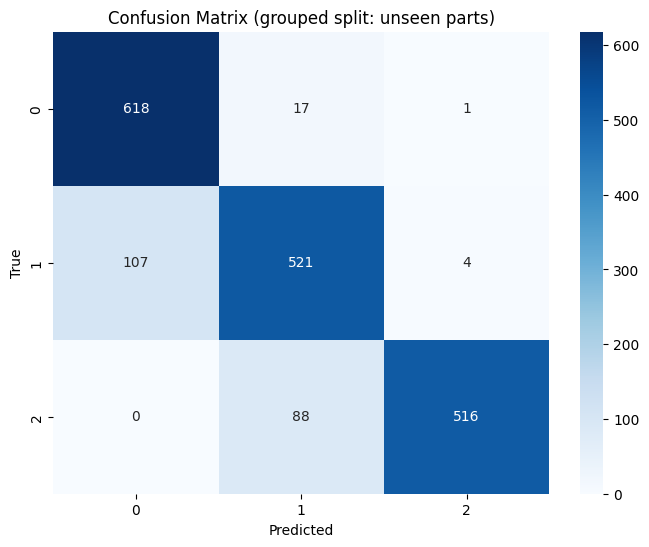


Classification Report (grouped split: unseen parts):
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       636
           1       0.83      0.82      0.83       632
           2       0.99      0.85      0.92       604

    accuracy                           0.88      1872
   macro avg       0.89      0.88      0.88      1872
weighted avg       0.89      0.88      0.88      1872

Test Accuracy: 0.8841
Macro F1:      0.8846
Fold 1: Acc=92.25% | Loss=0.2070 | MacroF1=0.9217
Fold 2: Acc=85.31% | Loss=0.3263 | MacroF1=0.8448
Fold 3: Acc=91.71% | Loss=0.2350 | MacroF1=0.9185
Fold 4: Acc=90.32% | Loss=0.2293 | MacroF1=0.9018
Fold 5: Acc=90.84% | Loss=0.2557 | MacroF1=0.9060

------------------------------------------------------------------------
Grouped CV summary (unseen parts each fold):
Accuracy: mean 90.08%  (± 2.48)
Macro F1: mean 0.8986 (± 0.0279)
Loss:     mean 0.2507
-----------------------------------------------------------------

In [5]:
# ===================== Imports & Reproducibility =====================
import warnings
warnings.filterwarnings('ignore')

import os
import random
import itertools
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ===================== Config =====================
# Exclude 'part' from features (still used for grouping)
DROP_PART = True

# Grid for exhaustive search
GRID = {
    'num_layers':    [1, 2, 3],
    'units':         [16, 32],
    'dropout_rate':  [0.0, 0.2],
    'l2_reg':        [0.0, 1e-4],
    'learning_rate': [1e-3, 3e-3, 1e-2]
}

# ===== Absolute path to Demand.csv (adjust only if your file moved) =====
file_path = r"/Users/yaeesh/Downloads/A Systematic AI-based Paradigm for Classifying Hybrid Electric Vehicle Spare Parts Using Their Price and Demand/Demand.csv"

# ===================== Load & clean =====================
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
print("Initial shape:", df.shape)

# Drop exact duplicates
dup_count = df.duplicated().sum()
print(f"Dropping {dup_count} duplicate rows" if dup_count else "0 duplicate rows")
if dup_count:
    df = df.drop_duplicates().reset_index(drop=True)

# ===================== Feature schema =====================
# NOTE: 'car total maintenance cost average' is intentionally treated as CATEGORICAL here
cat_cols = [
    'car type',
    'made in',
    'original/imitator',
    'new\\used',
    'selling location',
    'service location (repair shop/automotive company',
    'car total maintenance cost average',
    'part'  # identity-like; excluded from features if DROP_PART=True, but used for grouping
]

num_all = [
    'number of cars in jordan',
    'car age',
    'failure rate',
    'price of the car',
    'repair or replacement cost',
    'critically',
    'on line price'
]

missing_cols = [c for c in cat_cols + num_all + ['demand'] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns: {missing_cols}")

cat_cols_effective = [c for c in cat_cols if not (DROP_PART and c == 'part')]
X_all = df[cat_cols_effective + num_all].copy()
groups_all = df['part'].astype(str)  # for grouped splits

# For numeric transforms
skewed_cols = [
    'on line price',
    'number of cars in jordan',
    'failure rate',
    'repair or replacement cost',
    'critically',
    'price of the car'
]
other_num_cols = [c for c in num_all if c not in skewed_cols]

# ===================== Helper functions =====================
def compute_thresholds_from_train(demand_series, q_low=0.33, q_high=0.66):
    q = demand_series.quantile([q_low, q_high])
    return float(q.loc[q_low]), float(q.loc[q_high])

def bin_with_thresholds(demand_series, low_thr, high_thr):
    return pd.cut(demand_series,
                  bins=[-np.inf, low_thr, high_thr, np.inf],
                  labels=[0, 1, 2]).astype(int)

def make_preprocessor():
    numeric_skew_pipeline = Pipeline(steps=[
        ('log1p', FunctionTransformer(np.log1p, validate=False)),
        ('scaler', StandardScaler())
    ])
    numeric_pipeline = Pipeline(steps=[
        ('scaler', StandardScaler())
    ])
    # Version-compatible OneHotEncoder
    try:
        categorical_pipeline = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        categorical_pipeline = OneHotEncoder(handle_unknown='ignore', sparse=False)

    return ColumnTransformer(
        transformers=[
            ('num_skew', numeric_skew_pipeline, skewed_cols),
            ('num',     numeric_pipeline,       other_num_cols),
            ('cat',     categorical_pipeline,   cat_cols_effective)
        ],
        remainder='drop'
    )

def build_model(input_dim, num_layers, units, dropout_rate, l2_reg, learning_rate, num_classes=3):
    model = Sequential()
    reg = regularizers.l2(l2_reg) if l2_reg and l2_reg > 0 else None
    for i in range(num_layers):
        if i == 0:
            model.add(Dense(units, activation='relu', kernel_regularizer=reg, input_shape=(input_dim,)))
        else:
            model.add(Dense(units, activation='relu', kernel_regularizer=reg))
        if dropout_rate and dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def grid_combinations(grid_dict):
    keys = list(grid_dict.keys())
    for values in itertools.product(*(grid_dict[k] for k in keys)):
        yield dict(zip(keys, values))

def hash_rows(df_like):
    """Create a stable hash per row using the actual feature columns used by the model."""
    str_df = df_like.copy()
    for c in str_df.columns:
        if pd.api.types.is_float_dtype(str_df[c]) or pd.api.types.is_integer_dtype(str_df[c]):
            str_df[c] = str_df[c].astype(float).map(lambda x: f"{x:.12g}")
        else:
            str_df[c] = str_df[c].astype(str)
    concat = str_df.apply(lambda r: '||'.join(r.values.astype(str)), axis=1)
    return concat.map(lambda s: hashlib.md5(s.encode('utf-8')).hexdigest())

# ===================== Per-part purity (leakage hint) =====================
tmp_low, tmp_high = compute_thresholds_from_train(df['demand'])  # approximate
tmp_y = bin_with_thresholds(df['demand'], tmp_low, tmp_high)
part_class_counts = pd.crosstab(df['part'], tmp_y)
part_purity = part_class_counts.max(axis=1) / part_class_counts.sum(axis=1)
print("\nPer-part purity, top 10:")
print(part_purity.sort_values(ascending=False).head(10))
print(f"Mean per-part purity: {part_purity.mean():.4f}")

# ===================== Outer grouped train/test split =====================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X_all, None, groups=groups_all))

X_train_raw, X_test_raw = X_all.iloc[train_idx], X_all.iloc[test_idx]
groups_train, groups_test = groups_all.iloc[train_idx], groups_all.iloc[test_idx]
demand_train, demand_test = df['demand'].iloc[train_idx], df['demand'].iloc[test_idx]

# Create labels using thresholds from TRAIN ONLY
low_thr, high_thr = compute_thresholds_from_train(demand_train)
print(f"\nTrain-only thresholds: 33%={low_thr:.6f}, 66%={high_thr:.6f}")
y_train = bin_with_thresholds(demand_train, low_thr, high_thr)
y_test  = bin_with_thresholds(demand_test,  low_thr, high_thr)

# Class distribution check
print("\nClass distribution (train):")
print(y_train.value_counts().sort_index())
print("Class distribution (test):")
print(y_test.value_counts().sort_index())

# ===================== Row-hash overlap audit =====================
train_hash = hash_rows(X_train_raw)
test_hash  = hash_rows(X_test_raw)
overlap = set(train_hash).intersection(set(test_hash))
print(f"\nRow-hash overlap between train and test using model features: {len(overlap)} rows")
if len(overlap) > 0:
    print("WARNING: Identical feature rows detected across train and test. Investigate potential duplicates.")

# ===================== Exhaustive grid search with grouped inner validation =====================
inner_gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
inner_tr_idx, inner_val_idx = next(inner_gss.split(X_train_raw, y_train, groups=groups_train))
X_inner_tr_raw = X_train_raw.iloc[inner_tr_idx]
X_inner_val_raw = X_train_raw.iloc[inner_val_idx]
y_inner_tr = y_train.iloc[inner_tr_idx]
y_inner_val = y_train.iloc[inner_val_idx]

def fit_transform_preprocessor(X_tr_raw, X_val_raw):
    pre = make_preprocessor()
    X_tr = pre.fit_transform(X_tr_raw)
    X_val = pre.transform(X_val_raw)
    return pre, X_tr, X_val

best_cfg = None
best_val_f1 = -np.inf
best_model = None
best_history = None

total_combos = int(np.prod([len(v) for v in GRID.values()]))
print(f"\nStarting exhaustive grid search over {total_combos} combinations...")
for idx, cfg in enumerate(grid_combinations(GRID), start=1):
    print(f"Config {idx}/{total_combos}: {cfg}")
    pre_gs, X_inner_tr, X_inner_val = fit_transform_preprocessor(X_inner_tr_raw, X_inner_val_raw)
    input_dim = X_inner_tr.shape[1]

    model = build_model(
        input_dim=input_dim,
        num_layers=cfg['num_layers'],
        units=cfg['units'],
        dropout_rate=cfg['dropout_rate'],
        l2_reg=cfg['l2_reg'],
        learning_rate=cfg['learning_rate'],
        num_classes=3
    )

    early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)

    history = model.fit(
        X_inner_tr, y_inner_tr,
        epochs=200,
        validation_data=(X_inner_val, y_inner_val),
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    y_val_pred = np.argmax(model.predict(X_inner_val, verbose=0), axis=1)
    f1 = f1_score(y_inner_val, y_val_pred, average='macro')
    if f1 > best_val_f1:
        best_val_f1 = f1
        best_cfg = cfg
        best_model = model
        best_history = history
        best_preprocessor = pre_gs

print("\nBest grid configuration (inner grouped val macro F1):", round(best_val_f1, 4))
print(best_cfg)

# ===================== Retrain on full training set, with grouped inner val =====================
preprocessor_full = make_preprocessor()
X_train_proc = preprocessor_full.fit_transform(X_train_raw)
X_test_proc  = preprocessor_full.transform(X_test_raw)
input_dim = X_train_proc.shape[1]

inner_tr_idx2, inner_val_idx2 = next(inner_gss.split(X_train_raw, y_train, groups=groups_train))
X_tr2_raw, X_val2_raw = X_train_raw.iloc[inner_tr_idx2], X_train_raw.iloc[inner_val_idx2]
y_tr2, y_val2 = y_train.iloc[inner_tr_idx2], y_train.iloc[inner_val_idx2]
pre_ep = make_preprocessor()
X_tr2 = pre_ep.fit_transform(X_tr2_raw)
X_val2 = pre_ep.transform(X_val2_raw)

model = build_model(
    input_dim=input_dim,
    num_layers=best_cfg['num_layers'],
    units=best_cfg['units'],
    dropout_rate=best_cfg['dropout_rate'],
    l2_reg=best_cfg['l2_reg'],
    learning_rate=best_cfg['learning_rate'],
    num_classes=3
)

early_stop_final = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr_final  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)

history = model.fit(
    X_tr2, y_tr2,
    epochs=200,
    validation_data=(X_val2, y_val2),
    callbacks=[early_stop_final, reduce_lr_final],
    verbose=0
)

# ===================== Plots =====================
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.savefig('training_validation_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# ===================== Test evaluation (unseen parts) =====================
y_pred_proba = model.predict(X_test_proc, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = y_test.to_numpy()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.title('Confusion Matrix (grouped split: unseen parts)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nClassification Report (grouped split: unseen parts):")
print(classification_report(y_true, y_pred))
print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1:      {f1_score(y_true, y_pred, average='macro'):.4f}")

# ===================== Grouped CV with per-fold thresholds & preprocessing =====================
num_folds = 5
gkf = GroupKFold(n_splits=num_folds)

acc_per_fold, f1_per_fold, loss_per_fold = [], [], []
fold_no = 1
for tr_idx, val_idx in gkf.split(X_all, None, groups=groups_all):
    X_tr_raw, X_val_raw = X_all.iloc[tr_idx], X_all.iloc[val_idx]
    demand_tr, demand_val = df['demand'].iloc[tr_idx], df['demand'].iloc[val_idx]

    low_f, high_f = compute_thresholds_from_train(demand_tr)
    y_tr_f = bin_with_thresholds(demand_tr, low_f, high_f)
    y_val_f = bin_with_thresholds(demand_val, low_f, high_f)

    pre_fold = make_preprocessor()
    X_tr = pre_fold.fit_transform(X_tr_raw)
    X_val = pre_fold.transform(X_val_raw)

    model_fold = build_model(
        input_dim=X_tr.shape[1],
        num_layers=best_cfg['num_layers'],
        units=best_cfg['units'],
        dropout_rate=best_cfg['dropout_rate'],
        l2_reg=best_cfg['l2_reg'],
        learning_rate=best_cfg['learning_rate'],
        num_classes=3
    )

    hist_f = model_fold.fit(
        X_tr, y_tr_f,
        epochs=200,
        validation_data=(X_val, y_val_f),
        callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
                   ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)],
        verbose=0
    )

    loss, acc = model_fold.evaluate(X_val, y_val_f, verbose=0)
    y_val_pred = np.argmax(model_fold.predict(X_val, verbose=0), axis=1)
    f1 = f1_score(y_val_f, y_val_pred, average='macro')

    print(f"Fold {fold_no}: Acc={acc*100:.2f}% | Loss={loss:.4f} | MacroF1={f1:.4f}")
    acc_per_fold.append(acc * 100); f1_per_fold.append(f1); loss_per_fold.append(loss)
    fold_no += 1

print('\n' + '-'*72)
print('Grouped CV summary (unseen parts each fold):')
print(f"Accuracy: mean {np.mean(acc_per_fold):.2f}%  (± {np.std(acc_per_fold):.2f})")
print(f"Macro F1: mean {np.mean(f1_per_fold):.4f} (± {np.std(f1_per_fold):.4f})")
print(f"Loss:     mean {np.mean(loss_per_fold):.4f}")
print('-'*72)

# ===================== Single-feature leakage audit (grouped CV) =====================
def single_feature_cv_score(feature_name):
    if feature_name in cat_cols_effective:
        try:
            ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
        except TypeError:
            ohe = OneHotEncoder(handle_unknown='ignore', sparse=False)
        pipe = Pipeline([('ohe', ohe),
                         ('clf', LogisticRegression(max_iter=2000, multi_class='multinomial'))])
        X_feat = df[[feature_name]].astype(str)
    else:
        steps = []
        if feature_name in skewed_cols:
            steps.append(('log1p', FunctionTransformer(np.log1p, validate=False)))
        steps.append(('scaler', StandardScaler()))
        steps.append(('clf', LogisticRegression(max_iter=2000, multi_class='multinomial')))
        pipe = Pipeline(steps)
        X_feat = df[[feature_name]].copy()

    f1_scores = []
    for tr_idx, val_idx in gkf.split(X_all, None, groups=groups_all):
        d_tr = df['demand'].iloc[tr_idx]; d_val = df['demand'].iloc[val_idx]
        low_f, high_f = compute_thresholds_from_train(d_tr)
        y_tr_f = bin_with_thresholds(d_tr, low_f, high_f)
        y_val_f = bin_with_thresholds(d_val, low_f, high_f)

        X_tr_f = X_feat.iloc[tr_idx]; X_val_f = X_feat.iloc[val_idx]
        pipe.fit(X_tr_f, y_tr_f)
        y_val_pred = pipe.predict(X_val_f)
        f1_scores.append(f1_score(y_val_f, y_val_pred, average='macro'))

    return np.mean(f1_scores)

features_to_audit = cat_cols_effective + num_all
audit_results = []
print("\nRunning single-feature leakage audit (grouped CV, macro F1 per feature)...")
for feat in features_to_audit:
    score = single_feature_cv_score(feat)
    audit_results.append((feat, score))
audit_results.sort(key=lambda x: x[1], reverse=True)
print("Top 10 features by single-feature macro F1:")
for name, sc in audit_results[:10]:
    print(f"{name:45s} {sc:.4f}")

suspicious = [(n, s) for n, s in audit_results if s >= 0.99]
if suspicious:
    print("\nWARNING: These features alone achieve near-perfect classification under grouped CV:")
    for n, s in suspicious:
        print(f"  - {n}: macro F1 {s:.4f}")
    print("Review whether they encode target information directly or leak future knowledge.")

# ===================== Save tuned model & thresholds =====================
model.save("demand_clf.keras")
with open("label_thresholds.txt", "w") as f:
    f.write(f"{low_thr},{high_thr}\n")
print("\nSaved tuned model to demand_clf.keras")
print("Saved train-only label thresholds to label_thresholds.txt")
print("Best configuration:", GRID if best_cfg is None else best_cfg)
